In [ ]:
import rioxarray as rxr 
import geopandas as gpd
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from rasterio.enums import Resampling
from scipy import ndimage
import glob

## Basin selection and attributes

In [ ]:
BASIN = "Tuolumne_River"

In [ ]:
domain_attributes = xr.open_dataset(f"/scratch/dlhogan/ess-project-data/domain_{BASIN}_distributed_elev/settings/SUMMA/attributes.nc")
domain_elev_bands = domain_attributes['elevation'].values [::-1]

In [ ]:
gdf = gpd.read_file(f"/scratch/dlhogan/ess-project-data/domain_{BASIN}_lumped/shapefiles/catchment/{BASIN}_lumped_HRUs_GRUs.shp")
local_crs = {
    "East_River": "EPSG:32613",
    "Tuolumne_River": "EPSG:32611",   
    # Add other basins and their corresponding EPSG codes here as needed
}
gdf = gdf.to_crs(local_crs.get(BASIN))

## ASO flights and data assimilation

In [ ]:
aso_crs = da.rio.crs
dem = rxr.open_rasterio(f"/scratch/dlhogan/ess-project-data/domain_{BASIN}_distributed_elev/attributes/elevation/dem/domain_{BASIN}_lumped_elv.tif", masked=True).squeeze(drop=True)
# Resample DEM to ASO CRS at ~50 m.
dem = dem.rio.reproject(aso_crs, resolution=50)

In [ ]:
aso_files = sorted(Path(f"/scratch/dlhogan/ess-project-data/geospatial-data/ASO/{BASIN.split('_')[0]}").glob('*.tif'))
_swe = {}
for fp in aso_files:
    date = str(fp).split('_')[-1].split('.')[0]
    da = rxr.open_rasterio(fp, masked=True).squeeze(drop=True).astype("float32") * 1000
    # Physical filter: SWE cannot be negative; treat negatives as invalid/missing.
    _swe[date] = da.where(da >= 0)
    # clip to domain
    print(f"Clipping SWE for {date} to domain...")
    _swe[date] = _swe[date].rio.clip(gdf.geometry, gdf.crs, drop=True, all_touched=True)


Clipping SWE for 20220405 to domain...
Clipping SWE for 20220429 to domain...
Clipping SWE for 20220518 to domain...
Clipping SWE for 20230316 to domain...
Clipping SWE for 20230427 to domain...
Clipping SWE for 20230601 to domain...
Clipping SWE for 20230626 to domain...
Clipping SWE for 20240402 to domain...
Clipping SWE for 20240501 to domain...
Clipping SWE for 20250404 to domain...
Clipping SWE for 20260406 to domain...
Clipping SWE for 20130403 to domain...
Clipping SWE for 20130429 to domain...
Clipping SWE for 20130503 to domain...
Clipping SWE for 20130525 to domain...
Clipping SWE for 20130601 to domain...
Clipping SWE for 20130608 to domain...
Clipping SWE for 20140323 to domain...
Clipping SWE for 20140407 to domain...
Clipping SWE for 20140420 to domain...
Clipping SWE for 20140428 to domain...
Clipping SWE for 20140502 to domain...
Clipping SWE for 20140511 to domain...
Clipping SWE for 20140517 to domain...
Clipping SWE for 20140527 to domain...
Clipping SWE for 20140531

In [ ]:
# merge all SWE flights and save data

In [ ]:
ds = xr.open_dataset('/scratch/dlhogan/ess-project-data/domain_Tuolumne_River_distributed_elevAspect/simulations/best_simulations/distributed_elevAspect_qTopmodl_best_longterm.nc')
scalarSWE = ds['scalarSWE'].sel(time=slice('2005-07-31', '2005-09-1')).mean(dim='time')

Text(0.5, 1.0, '')

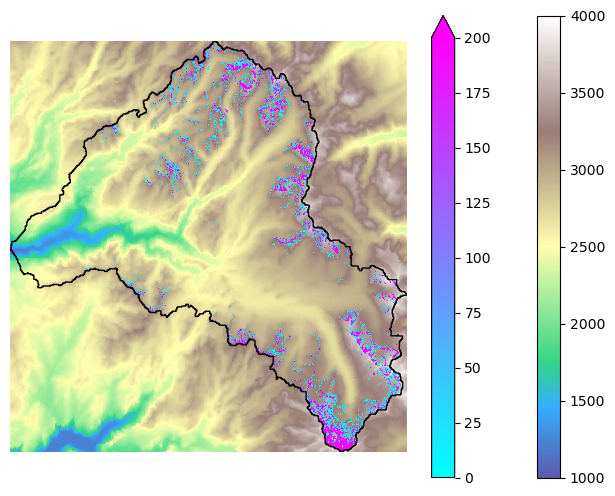

In [36]:
# plot DEM
fig, ax = plt.subplots(figsize=(8, 6))
dem.plot(vmin=1000, vmax=4000, cmap="terrain", ax=ax, alpha=0.8, )
gdf.boundary.plot(ax=ax, color='k', lw=1)
(_swe["20170816"].where(_swe["20170816"]>0)).plot(vmin=0, vmax=200, cmap="cool", ax=ax)
# turn axes off 
ax.set_axis_off()
ax.set_title("")

/tmp/ipykernel_933185/2013235316.py:2: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  plt.hist(scalarSWE.values, density=True, alpha=0.5, bins=6, label='SUMMA elev+Aspect SWE (2016-04-01)\nTotal basin SWE: {:.2e} m$^3$'.format(float(scalarSWE.mean().values / 1000 * gdf['HRU_area'])));


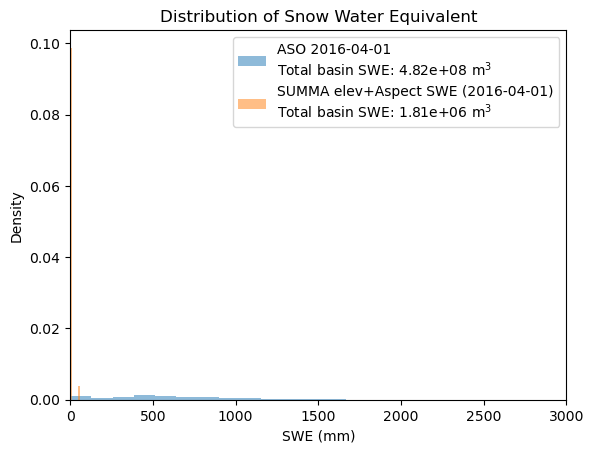

In [231]:
plt.hist((_swe['20160401']).to_numpy().flatten(), bins=25, density=True, alpha=0.5, label='ASO 2016-04-01\nTotal basin SWE: {:.2e} m$^3$'.format(float(_swe['20160401'].sum().values/1000 * 50*50)));
plt.hist(scalarSWE.values, density=True, alpha=0.5, bins=6, label='SUMMA elev+Aspect SWE (2016-04-01)\nTotal basin SWE: {:.2e} m$^3$'.format(float(scalarSWE.mean().values / 1000 * gdf['HRU_area'])));
plt.xlabel('SWE (mm)');
plt.ylabel('Density');
plt.title('Distribution of Snow Water Equivalent');
plt.legend();
plt.xlim(0,3000)
plt.show();

In [ ]:


def annulus_focal_mean(arr, pixel_size_m, irad_m, orad_m):
    orad_px = max(1, int(round(orad_m / pixel_size_m)))
    irad_px = max(0, int(round(irad_m / pixel_size_m)))
    yy, xx = np.ogrid[-orad_px:orad_px + 1, -orad_px:orad_px + 1]
    dist_m = np.sqrt(xx**2 + yy**2) * pixel_size_m
    kernel = ((dist_m <= orad_m) & (dist_m > irad_m)).astype(float)
    if kernel.sum() == 0:
        raise ValueError("Annulus kernel has zero weight; adjust radii or resolution.")

    valid = np.isfinite(arr).astype(float)
    filled = np.where(np.isfinite(arr), arr, 0.0)
    numer = ndimage.convolve(filled, kernel, mode="nearest")
    denom = ndimage.convolve(valid, kernel, mode="nearest")
    out = np.full_like(numer, np.nan, dtype=float)
    np.divide(numer, denom, out=out, where=denom > 0)
    return out

def classify_tpi_with_slope(tpi_vals, slope_deg_vals):
    tpi_mean = float(np.nanmean(tpi_vals))
    tpi_std = float(np.nanstd(tpi_vals))
    if not np.isfinite(tpi_std) or tpi_std == 0:
        raise ValueError("TPI standard deviation is zero/invalid.")
    tpi_stdi_vals = np.trunc((((tpi_vals - tpi_mean) / tpi_std) * 100.0) + 0.5)

    # 1 ridge > +1 std
    # 2 upper slope > 0.5 std and <= 1 std
    # 3 middle slope -0.5..0.5 std and slope > 5 deg
    # 4 flats -0.5..0.5 std and slope <= 5 deg
    # 5 lower slope >= -1 std and < -0.5 std
    # 6 valleys < -1 std
    tpi_z = (tpi_vals - tpi_mean) / tpi_std
    tpi_class_vals = np.full_like(tpi_z, np.nan, dtype=float)
    tpi_class_vals[(tpi_z > 1.0)] = 1
    tpi_class_vals[(tpi_z > 0.5) & (tpi_z <= 1.0)] = 2
    tpi_class_vals[(tpi_z >= -0.5) & (tpi_z <= 0.5) & (slope_deg_vals > 5.0)] = 3
    tpi_class_vals[(tpi_z >= -0.5) & (tpi_z <= 0.5) & (slope_deg_vals <= 5.0)] = 4
    tpi_class_vals[(tpi_z >= -1.0) & (tpi_z < -0.5)] = 5
    tpi_class_vals[(tpi_z < -1.0)] = 6

    return tpi_mean, tpi_std, tpi_stdi_vals, tpi_class_vals

# Terrain derivatives.
x_step = float(dem.x.values[1] - dem.x.values[0])
y_step = float(dem.y.values[1] - dem.y.values[0])
cell_size_m = float(np.mean([abs(x_step), abs(y_step)]))
dz_dy, dz_dx = np.gradient(dem.values, y_step, x_step)

# Slope in degrees.
slope_deg_vals = np.degrees(np.arctan(np.hypot(dz_dx, dz_dy)))

# Aspect in compass convention: degrees clockwise from North.
ASPECT_OFFSET_DEG = 0.0
vx = -dz_dx
vy = -dz_dy
aspect_vals = (np.degrees(np.arctan2(vx, vy)) + 360.0) % 360.0
aspect_vals = (aspect_vals + ASPECT_OFFSET_DEG) % 360.0

# TPI at scale factors 300 m, 1000 m, and 2000 m using annulus focal mean.
# Formula target: tpi<sf> = int((dem - focalmean(annulus)) + 0.5)
fmean_300 = annulus_focal_mean(dem.values, cell_size_m, irad_m=0.0, orad_m=300.0)
tpi300_vals = np.trunc((dem.values - fmean_300) + 0.5)
fmean_1000 = annulus_focal_mean(dem.values, cell_size_m, irad_m=0.0, orad_m=1000.0)
tpi1000_vals = np.trunc((dem.values - fmean_1000) + 0.5)
fmean_2000 = annulus_focal_mean(dem.values, cell_size_m, irad_m=0.0, orad_m=2000.0)
tpi2000_vals = np.trunc((dem.values - fmean_2000) + 0.5)

# Standardized forms + classes for 300 and 1000 m scales.
tpi300_mean, tpi300_std, tpi300_stdi_vals, tpi300_class_vals = classify_tpi_with_slope(
    tpi300_vals, slope_deg_vals
)
tpi1000_mean, tpi1000_std, tpi1000_stdi_vals, tpi1000_class_vals = classify_tpi_with_slope(
    tpi1000_vals, slope_deg_vals
)

# Standardize 2000 m scale for composite plane.
tpi2000_mean = float(np.nanmean(tpi2000_vals))
tpi2000_std = float(np.nanstd(tpi2000_vals))
if not np.isfinite(tpi2000_std) or tpi2000_std == 0:
    raise ValueError("TPI2000 standard deviation is zero/invalid.")
tpi2000_stdi_vals = np.trunc((((tpi2000_vals - tpi2000_mean) / tpi2000_std) * 100.0) + 0.5)

# Composite class plane from tp300_stdi x tp2000_stdi + slope.
lf300x2k_vals = np.full_like(tpi300_stdi_vals, np.nan, dtype=float)
tp300_center = (tpi300_stdi_vals > -100) & (tpi300_stdi_vals < 100)
tp2000_center = (tpi2000_stdi_vals > -100) & (tpi2000_stdi_vals < 100)
tp300_low = tpi300_stdi_vals <= -100
tp300_high = tpi300_stdi_vals >= 100
tp2000_low = tpi2000_stdi_vals <= -100
tp2000_high = tpi2000_stdi_vals >= 100

lf300x2k_vals[tp300_center & tp2000_center & (slope_deg_vals <= 5)] = 5
lf300x2k_vals[tp300_center & tp2000_center & (slope_deg_vals >= 6)] = 6
lf300x2k_vals[tp300_center & tp2000_high] = 7
lf300x2k_vals[tp300_center & tp2000_low] = 4
lf300x2k_vals[tp300_low & tp2000_center] = 2
lf300x2k_vals[tp300_high & tp2000_center] = 9
lf300x2k_vals[tp300_low & tp2000_high] = 3
lf300x2k_vals[tp300_low & tp2000_low] = 1
lf300x2k_vals[tp300_high & tp2000_high] = 10
lf300x2k_vals[tp300_high & tp2000_low] = 8

# Keep geospatial metadata by copying DEM template.
aspect_dem = dem.copy(data=aspect_vals).rename("aspect")
slope_deg_dem = dem.copy(data=slope_deg_vals).rename("slope_deg")
tpi300_dem = dem.copy(data=tpi300_vals).rename("tpi300")
tpi300_stdi_dem = dem.copy(data=tpi300_stdi_vals).rename("tpi300_stdi")
tpi300_class_dem = dem.copy(data=tpi300_class_vals).rename("tpi300_class")
tpi1000_dem = dem.copy(data=tpi1000_vals).rename("tpi1000")
tpi1000_stdi_dem = dem.copy(data=tpi1000_stdi_vals).rename("tpi1000_stdi")
tpi1000_class_dem = dem.copy(data=tpi1000_class_vals).rename("tpi1000_class")
tpi2000_stdi_dem = dem.copy(data=tpi2000_stdi_vals).rename("tpi2000_stdi")
lf300x2k_dem = dem.copy(data=lf300x2k_vals).rename("lf300x2k")

valid_dem = np.isfinite(dem.values)
aspect_dem = aspect_dem.where(valid_dem)
slope_deg_dem = slope_deg_dem.where(valid_dem)
tpi300_dem = tpi300_dem.where(valid_dem)
tpi300_stdi_dem = tpi300_stdi_dem.where(valid_dem)
tpi300_class_dem = tpi300_class_dem.where(valid_dem)
tpi1000_dem = tpi1000_dem.where(valid_dem)
tpi1000_stdi_dem = tpi1000_stdi_dem.where(valid_dem)
tpi1000_class_dem = tpi1000_class_dem.where(valid_dem)
tpi2000_stdi_dem = tpi2000_stdi_dem.where(valid_dem)
lf300x2k_dem = lf300x2k_dem.where(valid_dem)

## Topographic Positional Index for classifying SWE 

In [105]:
# Build SWE/topography variables with dimensions: time, y, x.
# ASO rasters come on slightly different grids; reproject all dates to one template grid
# to avoid interleaved-column artifacts during alignment/averaging.
date_keys = sorted(_swe.keys())
date_index = pd.to_datetime(date_keys)

# Use the largest raster as the common target grid (max extent/resolution).
template_date = max(date_keys, key=lambda d: _swe[d].sizes["x"] * _swe[d].sizes["y"])
template = _swe[template_date]

swe_layers = []
for date in date_keys:
    da = _swe[date]
    da_match = da.rio.reproject_match(template, nodata=np.nan)
    swe_layers.append(da_match)

# Concatenate into a time stack; areas outside a date's footprint remain NaN.
swe = xr.concat(swe_layers, dim=pd.Index(date_index, name="time")).rename("swe")

# Footprint cleanup: keep only cells that have positive SWE at least once
# (removes persistent off-domain zeros), then apply same mask to static fields.
valid_footprint = (swe > 0).any(dim="time")
swe = swe.where(valid_footprint)

# Match topographic fields to the same grid using nearest-neighbor assignment.
elevation = (
    dem.rio.reproject_match(template, resampling=Resampling.nearest, nodata=np.nan)
    .rename("elevation")
    .where(valid_footprint)
)
aspect = (
    aspect_dem.rio.reproject_match(template, resampling=Resampling.nearest, nodata=np.nan)
    .rename("aspect")
    .where(valid_footprint)
)
slope_deg = (
    slope_deg_dem.rio.reproject_match(template, resampling=Resampling.nearest, nodata=np.nan)
    .rename("slope_deg")
    .where(valid_footprint)
)
tpi300 = (
    tpi300_dem.rio.reproject_match(template, resampling=Resampling.nearest, nodata=np.nan)
    .rename("tpi300")
    .where(valid_footprint)
)
tpi300_stdi = (
    tpi300_stdi_dem.rio.reproject_match(template, resampling=Resampling.nearest, nodata=np.nan)
    .rename("tpi300_stdi")
    .where(valid_footprint)
)
tpi300_class = (
    tpi300_class_dem.rio.reproject_match(template, resampling=Resampling.nearest, nodata=np.nan)
    .rename("tpi300_class")
    .where(valid_footprint)
)
tpi1000 = (
    tpi1000_dem.rio.reproject_match(template, resampling=Resampling.nearest, nodata=np.nan)
    .rename("tpi1000")
    .where(valid_footprint)
)
tpi1000_stdi = (
    tpi1000_stdi_dem.rio.reproject_match(template, resampling=Resampling.nearest, nodata=np.nan)
    .rename("tpi1000_stdi")
    .where(valid_footprint)
)
tpi1000_class = (
    tpi1000_class_dem.rio.reproject_match(template, resampling=Resampling.nearest, nodata=np.nan)
    .rename("tpi1000_class")
    .where(valid_footprint)
)
tpi2000_stdi = (
    tpi2000_stdi_dem.rio.reproject_match(template, resampling=Resampling.nearest, nodata=np.nan)
    .rename("tpi2000_stdi")
    .where(valid_footprint)
)
lf300x2k = (
    lf300x2k_dem.rio.reproject_match(template, resampling=Resampling.nearest, nodata=np.nan)
    .rename("lf300x2k")
    .where(valid_footprint)
)

# Merge SWE + topography on shared x/y coordinates.
swe_ds = xr.Dataset({
    "swe": swe,
    "elevation": elevation,
    "aspect": aspect,
    "slope_deg": slope_deg,
    "tpi300": tpi300,
    "tpi300_stdi": tpi300_stdi,
    "tpi300_class": tpi300_class,
    "tpi1000": tpi1000,
    "tpi1000_stdi": tpi1000_stdi,
    "tpi1000_class": tpi1000_class,
    "tpi2000_stdi": tpi2000_stdi,
    "lf300x2k": lf300x2k,
})

# Trim all-NaN edges in spatial dimensions.
swe_ds = swe_ds.dropna(dim="x", how="all").dropna(dim="y", how="all")

In [107]:
# Peak-SWE proxy subset: earliest flight in each year during a May-July window.
elev = swe_ds["elevation"]
aspect = swe_ds["aspect"]
tpi1000_class = swe_ds["tpi1000_class"]
swe_all = swe_ds["swe"]

# Streamflow year groups - updated to include full record.
DRY_YEARS = {2014, 2015, 2021, 2018, 2026}
NORMAL_YEARS = {2013, 2016, 2019, 2020, 2022, 2024, 2025}
WET_YEARS = {2017, 2023}

def flow_group_from_year(y):
    if y in DRY_YEARS:
        return "dry"
    if y in NORMAL_YEARS:
        return "normal"
    if y in WET_YEARS:
        return "wet"
    return "other"

all_times = pd.DatetimeIndex(pd.to_datetime(swe_all.time.values)).sort_values()
window_mask = all_times.month.isin([3,4,5])
window_times = all_times[window_mask]

selected_flights = (
    pd.DataFrame({"time": window_times})
    .assign(year=lambda d: d["time"].dt.year)
    .sort_values("time")
    .groupby("year", as_index=False)
    .first()
)

if selected_flights.empty:
    raise ValueError("No flights found in May-July window. Adjust the date window.")

selected_flights["flow_group"] = selected_flights["year"].map(flow_group_from_year)
selected_times = selected_flights["time"].tolist()
swe_peak = swe_all.sel(time=selected_times)

# ---------------------------------------------------------------------------
# Elevation bins derived from domain HRU centroids (domain_elev_bands).
# Edges sit halfway between adjacent centroids so each pixel is assigned to
# its nearest HRU centroid band. band_mid_m will equal the HRU centroid.
# ---------------------------------------------------------------------------
_centroids = np.sort(domain_elev_bands)  # 9 values, low -> high
_inner_edges = (_centroids[:-1] + _centroids[1:]) / 2
elev_bins = np.concatenate([
    [_centroids[0] - (_inner_edges[0] - _centroids[0])],
    _inner_edges,
    [_centroids[-1] + (_centroids[-1] - _inner_edges[-1])],
])
print(f"Using {len(_centroids)} HRU-based elevation bands")
for lo, hi, cen in zip(elev_bins[:-1], elev_bins[1:], _centroids):
    print(f"  [{lo:.0f}, {hi:.0f})  centroid = {cen:.0f} m")

# 1) Elevation-only CV. Keep CV definition as std/mean.
elev_group = swe_peak.groupby_bins(elev, bins=elev_bins, right=False, include_lowest=True)
spatial_dims = [d for d in elev_group.dims if d != "time"]
elev_mean = elev_group.mean(dim=spatial_dims, skipna=True)
elev_median = elev_group.median(dim=spatial_dims, skipna=True)
elev_std = elev_group.std(dim=spatial_dims, skipna=True)
elev_count = elev_group.count(dim=spatial_dims)
elev_cv = xr.where((elev_mean > 0) & (elev_count > 1), elev_std / elev_mean, np.nan)

cv_peak_by_elev = (
    xr.Dataset({
        "cv": elev_cv.rename("cv"),
        "swe_mean": elev_mean.rename("swe_mean"),
        "swe_std": elev_std.rename("swe_std"),
        "n_pixels": elev_count.rename("n_pixels"),
    })
    .to_dataframe()
    .reset_index()
    .dropna(subset=["cv"])
)
cv_peak_by_elev["year"] = pd.to_datetime(cv_peak_by_elev["time"]).dt.year
cv_peak_by_elev["flow_group"] = cv_peak_by_elev["year"].map(flow_group_from_year)
cv_peak_by_elev["band_lower_m"] = cv_peak_by_elev["elevation_bins"].apply(lambda iv: iv.left)
cv_peak_by_elev["band_upper_m"] = cv_peak_by_elev["elevation_bins"].apply(lambda iv: iv.right)
cv_peak_by_elev["band_mid_m"] = 0.5 * (
    cv_peak_by_elev["band_lower_m"] + cv_peak_by_elev["band_upper_m"]
)

cv_elev_summary = (
    cv_peak_by_elev.groupby("elevation_bins", observed=True)
    .agg(
        cv_mean=("cv", "mean"),
        cv_median=("cv", "median"),
        cv_std=("cv", "std"),
        n_years=("year", "nunique"),
        mean_pixels=("n_pixels", "mean"),
    )
    .reset_index()
    .sort_values("elevation_bins")
)
cv_elev_summary["band_lower_m"] = cv_elev_summary["elevation_bins"].apply(lambda iv: iv.left)
cv_elev_summary["band_upper_m"] = cv_elev_summary["elevation_bins"].apply(lambda iv: iv.right)
cv_elev_summary["band_mid_m"] = 0.5 * (
    cv_elev_summary["band_lower_m"] + cv_elev_summary["band_upper_m"]
)

cv_elev_wetdry_summary = (
    cv_peak_by_elev[cv_peak_by_elev["flow_group"].isin(["dry", "normal", "wet"])]
    .groupby(["elevation_bins", "flow_group"], observed=True)
    .agg(
        cv_mean=("cv", "mean"),
        cv_median=("cv", "median"),
        cv_std=("cv", "std"),
        n_years=("year", "nunique"),
        mean_pixels=("n_pixels", "mean"),
    )
    .reset_index()
)
cv_elev_wetdry_summary["band_lower_m"] = cv_elev_wetdry_summary["elevation_bins"].apply(lambda iv: iv.left)
cv_elev_wetdry_summary["band_upper_m"] = cv_elev_wetdry_summary["elevation_bins"].apply(lambda iv: iv.right)
cv_elev_wetdry_summary["band_mid_m"] = 0.5 * (
    cv_elev_wetdry_summary["band_lower_m"] + cv_elev_wetdry_summary["band_upper_m"]
)

# 1b) Percent above/below basin median SWE for each selected flight, by elevation band.
basin_median = swe_peak.median(dim=("y", "x"), skipna=True)
valid_mask = swe_peak.notnull()
above = xr.where(valid_mask, (swe_peak > basin_median).astype(float), np.nan)
below = xr.where(valid_mask, (swe_peak < basin_median).astype(float), np.nan)

above_group = above.groupby_bins(elev, bins=elev_bins, right=False, include_lowest=True)
below_group = below.groupby_bins(elev, bins=elev_bins, right=False, include_lowest=True)
pct_above = (above_group.mean(dim=spatial_dims, skipna=True) * 100.0).rename("pct_above")
pct_below = (below_group.mean(dim=spatial_dims, skipna=True) * 100.0).rename("pct_below")
pct_count = elev_group.count(dim=spatial_dims).rename("n_pixels")

pct_peak_by_elev = (
    xr.Dataset({
        "pct_above": pct_above,
        "pct_below": pct_below,
        "n_pixels": pct_count,
    })
    .to_dataframe()
    .reset_index()
    .dropna(subset=["pct_above", "pct_below"])
)
pct_peak_by_elev["year"] = pd.to_datetime(pct_peak_by_elev["time"]).dt.year
pct_peak_by_elev["flow_group"] = pct_peak_by_elev["year"].map(flow_group_from_year)
pct_peak_by_elev["band_lower_m"] = pct_peak_by_elev["elevation_bins"].apply(lambda iv: iv.left)
pct_peak_by_elev["band_upper_m"] = pct_peak_by_elev["elevation_bins"].apply(lambda iv: iv.right)
pct_peak_by_elev["band_mid_m"] = 0.5 * (
    pct_peak_by_elev["band_lower_m"] + pct_peak_by_elev["band_upper_m"]
)

pct_elev_summary = (
    pct_peak_by_elev.groupby("elevation_bins", observed=True)
    .agg(
        pct_above_mean=("pct_above", "mean"),
        pct_below_mean=("pct_below", "mean"),
        n_years=("year", "nunique"),
        mean_pixels=("n_pixels", "mean"),
    )
    .reset_index()
    .sort_values("elevation_bins")
)
pct_elev_summary["band_lower_m"] = pct_elev_summary["elevation_bins"].apply(lambda iv: iv.left)
pct_elev_summary["band_upper_m"] = pct_elev_summary["elevation_bins"].apply(lambda iv: iv.right)
pct_elev_summary["band_mid_m"] = 0.5 * (
    pct_elev_summary["band_lower_m"] + pct_elev_summary["band_upper_m"]
)

pct_elev_wetdry_summary = (
    pct_peak_by_elev[pct_peak_by_elev["flow_group"].isin(["dry", "normal", "wet"])]
    .groupby(["elevation_bins", "flow_group"], observed=True)
    .agg(
        pct_above_mean=("pct_above", "mean"),
        pct_below_mean=("pct_below", "mean"),
        n_years=("year", "nunique"),
        mean_pixels=("n_pixels", "mean"),
    )
    .reset_index()
)
pct_elev_wetdry_summary["band_lower_m"] = pct_elev_wetdry_summary["elevation_bins"].apply(lambda iv: iv.left)
pct_elev_wetdry_summary["band_upper_m"] = pct_elev_wetdry_summary["elevation_bins"].apply(lambda iv: iv.right)
pct_elev_wetdry_summary["band_mid_m"] = 0.5 * (
    pct_elev_wetdry_summary["band_lower_m"] + pct_elev_wetdry_summary["band_upper_m"]
)

# 2) Elevation + aspect CV.
aspect_masks = {
    "NE": (aspect >= 0) & (aspect < 90),
    "SE": (aspect >= 90) & (aspect < 180),
    "SW": (aspect >= 180) & (aspect < 270),
    "NW": (aspect >= 270) & (aspect < 360),
}

ea_rows = []
for aspect_bin, mask in aspect_masks.items():
    swe_a = swe_peak.where(mask)
    band_group = swe_a.groupby_bins(elev, bins=elev_bins, right=False, include_lowest=True)
    spatial_dims2 = [d for d in band_group.dims if d != "time"]
    mean_ea = band_group.mean(dim=spatial_dims2, skipna=True)
    median_ea = band_group.median(dim=spatial_dims2, skipna=True)
    std_ea = band_group.std(dim=spatial_dims2, skipna=True)
    count_ea = band_group.count(dim=spatial_dims2)
    cv_ea = xr.where((mean_ea > 0) & (count_ea > 1), std_ea / mean_ea, np.nan)
    df_ea = (
        xr.Dataset({
            "cv": cv_ea.rename("cv"),
            "swe_mean": mean_ea.rename("swe_mean"),
            "swe_std": std_ea.rename("swe_std"),
            "n_pixels": count_ea.rename("n_pixels"),
        })
        .to_dataframe()
        .reset_index()
        .dropna(subset=["cv"])
    )
    if not df_ea.empty:
        df_ea["aspect_bin"] = aspect_bin
        df_ea["year"] = pd.to_datetime(df_ea["time"]).dt.year
        ea_rows.append(df_ea)

cv_peak_by_elev_aspect = pd.concat(ea_rows, ignore_index=True)
cv_peak_by_elev_aspect["band_lower_m"] = cv_peak_by_elev_aspect["elevation_bins"].apply(lambda iv: iv.left)
cv_peak_by_elev_aspect["band_upper_m"] = cv_peak_by_elev_aspect["elevation_bins"].apply(lambda iv: iv.right)
cv_peak_by_elev_aspect["band_mid_m"] = 0.5 * (
    cv_peak_by_elev_aspect["band_lower_m"] + cv_peak_by_elev_aspect["band_upper_m"]
)

cv_peak_elev_aspect_summary = (
    cv_peak_by_elev_aspect.groupby(["elevation_bins", "aspect_bin"], observed=True)
    .agg(
        cv_mean=("cv", "mean"),
        cv_median=("cv", "median"),
        cv_std=("cv", "std"),
        n_years=("year", "nunique"),
        mean_pixels=("n_pixels", "mean"),
    )
    .reset_index()
)
cv_peak_elev_aspect_summary["band_lower_m"] = cv_peak_elev_aspect_summary["elevation_bins"].apply(lambda iv: iv.left)
cv_peak_elev_aspect_summary["band_upper_m"] = cv_peak_elev_aspect_summary["elevation_bins"].apply(lambda iv: iv.right)
cv_peak_elev_aspect_summary["band_mid_m"] = 0.5 * (
    cv_peak_elev_aspect_summary["band_lower_m"] + cv_peak_elev_aspect_summary["band_upper_m"]
)

# 3) Elevation + TPI1000 class CV (ridges included as class 1).
tpi1000_labels = {
    1: "ridge",
    2: "upper_slope",
    3: "middle_slope",
    4: "flats",
    5: "lower_slope",
    6: "valley",
}

et_rows = []
for cls in [1, 2, 3, 4, 5, 6]:
    mask = tpi1000_class == cls
    swe_t = swe_peak.where(mask)
    band_group = swe_t.groupby_bins(elev, bins=elev_bins, right=False, include_lowest=True)
    spatial_dims2 = [d for d in band_group.dims if d != "time"]
    mean_et = band_group.mean(dim=spatial_dims2, skipna=True)
    median_et = band_group.median(dim=spatial_dims2, skipna=True)
    std_et = band_group.std(dim=spatial_dims2, skipna=True)
    count_et = band_group.count(dim=spatial_dims2)
    cv_et = xr.where((mean_et > 0) & (count_et > 1), std_et / mean_et, np.nan)
    df_et = (
        xr.Dataset({
            "cv": cv_et.rename("cv"),
            "swe_mean": mean_et.rename("swe_mean"),
            "swe_std": std_et.rename("swe_std"),
            "n_pixels": count_et.rename("n_pixels"),
        })
        .to_dataframe()
        .reset_index()
        .dropna(subset=["cv"])
    )
    if not df_et.empty:
        df_et["tpi1000_class"] = cls
        df_et["tpi1000_label"] = tpi1000_labels[cls]
        df_et["year"] = pd.to_datetime(df_et["time"]).dt.year
        df_et["flow_group"] = df_et["year"].map(flow_group_from_year)
        et_rows.append(df_et)

cv_peak_by_elev_tpi1000 = pd.concat(et_rows, ignore_index=True)
cv_peak_by_elev_tpi1000["band_lower_m"] = cv_peak_by_elev_tpi1000["elevation_bins"].apply(lambda iv: iv.left)
cv_peak_by_elev_tpi1000["band_upper_m"] = cv_peak_by_elev_tpi1000["elevation_bins"].apply(lambda iv: iv.right)
cv_peak_by_elev_tpi1000["band_mid_m"] = 0.5 * (
    cv_peak_by_elev_tpi1000["band_lower_m"] + cv_peak_by_elev_tpi1000["band_upper_m"]
)

cv_peak_elev_tpi1000_summary = (
    cv_peak_by_elev_tpi1000.groupby(["elevation_bins", "tpi1000_class", "tpi1000_label"], observed=True)
    .agg(
        cv_mean=("cv", "mean"),
        cv_median=("cv", "median"),
        cv_std=("cv", "std"),
        n_years=("year", "nunique"),
        mean_pixels=("n_pixels", "mean"),
    )
    .reset_index()
)
cv_peak_elev_tpi1000_summary["band_lower_m"] = cv_peak_elev_tpi1000_summary["elevation_bins"].apply(lambda iv: iv.left)
cv_peak_elev_tpi1000_summary["band_upper_m"] = cv_peak_elev_tpi1000_summary["elevation_bins"].apply(lambda iv: iv.right)
cv_peak_elev_tpi1000_summary["band_mid_m"] = 0.5 * (
    cv_peak_elev_tpi1000_summary["band_lower_m"] + cv_peak_elev_tpi1000_summary["band_upper_m"]
)

# print(f"Years with ASO flights: {sorted(selected_flights['year'].tolist())}")
# print(selected_flights[["year", "time", "flow_group"]].to_string(index=False))
# selected_flights, cv_elev_summary[["elevation_bins", "cv_mean", "cv_median", "cv_std", "n_years", "mean_pixels"]]

Using 5 HRU-based elevation bands
  [2522, 2849)  centroid = 2686 m
  [2849, 3187)  centroid = 3012 m
  [3187, 3528)  centroid = 3361 m
  [3528, 3846)  centroid = 3695 m
  [3846, 4148)  centroid = 3997 m


## Model Forcing Precipitation v. ASO SWE by elevation

In [65]:
# get tuolumne precipitation data from forcining
FORCING_DIR = Path(F"/scratch/dlhogan/ess-project-data/domain_{BASIN}_distributed/forcing")
precip_files = sorted(glob.glob(str(FORCING_DIR / "SUMMA_input" / "*metsim*.nc")))

ppt_dss = []
for file in precip_files:
    ds = xr.open_dataset(file)['pptrate'].resample(time='1D').mean()*3600*24
    ppt_dss.append(ds)
    ds.close()

# merge datasets
wy_precip_elev = xr.concat(ppt_dss, dim='time').resample(time='YS-OCT').sum()
winter_precip_elev = xr.concat(ppt_dss, dim='time')
# water year winter is december - march
winter_precip_elev = winter_precip_elev.where(winter_precip_elev['time.month'].isin([12, 1, 2, 3])).resample(time='YS-DEC').sum()

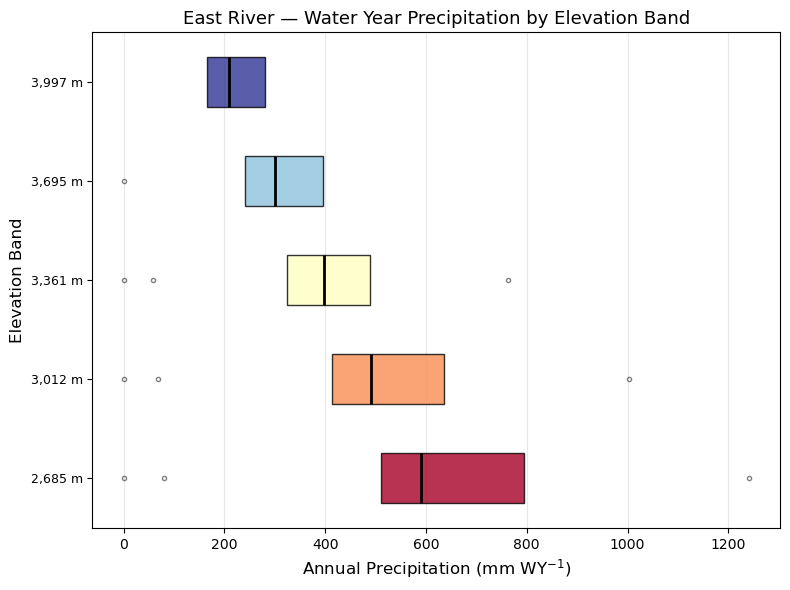

In [66]:
# Horizontal boxplot: distribution of water year precipitation by elevation band
precip_arr = winter_precip_elev.values        # (n_years, n_hrus)
n_hrus = precip_arr.shape[1]

# Sort low -> high so lowest elevation is at the bottom of the plot
sort_idx = np.argsort(domain_elev_bands)
elevs_sorted = domain_elev_bands[sort_idx]
data_sorted = [precip_arr[:, i] for i in sort_idx]
labels_sorted = [f"{int(e):,} m" for e in elevs_sorted]

fig, ax = plt.subplots(figsize=(8, max(6, n_hrus * 0.6)))

bp = ax.boxplot(
    data_sorted,
    vert=False,
    patch_artist=True,
    medianprops=dict(color="black", linewidth=2),
    flierprops=dict(marker="o", markersize=3, alpha=0.5, linestyle="none"),
    # remove whiskers and caps for cleaner look
    whiskerprops=dict(color="none"),
    capprops=dict(color="none")
)

# Color boxes by elevation: warm (low) -> cool (high)
cmap = plt.cm.RdYlBu
for i, patch in enumerate(bp["boxes"]):
    patch.set_facecolor(cmap(i / max(1, n_hrus - 1)))
    patch.set_alpha(0.8)

ax.set_yticks(range(1, n_hrus + 1))
ax.set_yticklabels(labels_sorted, fontsize=9)
ax.set_xlabel("Annual Precipitation (mm WY$^{-1}$)", fontsize=12)
ax.set_ylabel("Elevation Band", fontsize=12)
ax.set_title(f"{BASIN.replace(chr(95), chr(32))} — Water Year Precipitation by Elevation Band", fontsize=13)
ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

In [76]:
# model_output = xr.open_dataset("/scratch/dlhogan/ess-project-data/domain_East_River_distributed/simulations/baseline_longterm_20260426_184853/output/distributed_elev_noXplict_best_longterm.nc")
model_output = xr.open_dataset("/scratch/dlhogan/ess-project-data/domain_East_River_distributed/simulations/best_simulations/distributed_elevation_noXplict_best_longterm.nc")
# resample to daily mean swe
model_output_swe = model_output['scalarSWE'].resample(time='1D').mean()
# spring flights 
yearly_median_swe = {}
matching_obs_swe = {}
flight_dates = []
spring_flights = swe_ds.sel(time=swe_ds.time.dt.month.isin([1,2,3,4,5,6]))
# flights between 2013 and 2021
spring_flights = spring_flights.sel(time=slice("2013-01-01", "2024-12-31"))
spring_flight_median_swe = spring_flights.median(dim=['x','y'], skipna=True)
for year in np.arange(2013, 2024):
    year_mask = spring_flight_median_swe.time.dt.year == year
    median_swe_year = spring_flight_median_swe['swe'].sel(time=year_mask).to_pandas().max()
    if not np.isfinite(median_swe_year):
        print(f"Warning: No valid SWE for year {year}. Skipping.")
        continue
    flight_date = spring_flight_median_swe['swe'].sel(time=year_mask).to_pandas().idxmax()
    yearly_median_swe[year] = median_swe_year
    flight_dates.append(flight_date)

    # find closest model output time to flight date
    model_output_time = model_output_swe.time.sel(time=flight_date, method='nearest')
    matching_obs_swe[year] = model_output_swe.sel(time=model_output_time)

In [77]:
# convert to dataframe
yearly_median_swe_df = pd.DataFrame({
    'year': list(yearly_median_swe.keys()),
    'median_swe': list(yearly_median_swe.values())
}).set_index('year').sort_index()
yearly_median_swe_df.index = pd.to_datetime(yearly_median_swe_df.index, format='%Y')
yearly_median_swe_df['median_swe'] = yearly_median_swe_df['median_swe'].astype(float)

In [78]:
obs_precip = pd.read_csv("/scratch/dlhogan/ess-project-data/domain_Tuolumne_River_distributed_elev/observations/snow/01_TUM_TUOLUMNE_MEADOWS_cdec_obs.csv", parse_dates=["datetime"],index_col="datetime")
obs_ppt_mm = obs_precip['PRECIPITATION']*25.4
# filter out any value above 400 mm/day
obs_ppt_mm = obs_ppt_mm[obs_ppt_mm < 400]
# filter any value below 0 mm/day
obs_ppt_mm = obs_ppt_mm[obs_ppt_mm >= 0]
wy_obs_ppt_mm = obs_ppt_mm.resample('YS-OCT').sum()
dec_mar_obs_ppt_mm = obs_ppt_mm[obs_ppt_mm.index.month.isin([12, 1, 2, 3])].resample('YS-DEC').sum()
dec_mar_obs_ppt_mm = dec_mar_obs_ppt_mm.loc[(dec_mar_obs_ppt_mm.index.year >= 2012) & (dec_mar_obs_ppt_mm.index.year <= 2023)]

In [79]:
# =====================================================================
# MODEL PRECIP vs ASO SWE — elevation gradient comparison
# Each point = median across water years (model) or spring flights (ASO)
# Whiskers = IQR (Q25–Q75) across those years/flights
# Both normalized to their own basin mean for direct shape comparison
# =====================================================================

# --- Elevation bands sorted ascending ---
sort_idx = np.argsort(domain_elev_bands)
elevs_sorted = domain_elev_bands[sort_idx].astype(float)  # (n_hrus,) m, ascending
n_hrus = len(elevs_sorted)

# True ascending sort from the unflipped attribute file (sort_idx may be identity
# because domain_elev_bands is already flipped ascending in Cell 3).
_asc = np.argsort(domain_attributes["elevation"].values)  # 1396m→3681m
hru_area_ascending = domain_attributes["HRUarea"].values[_asc].astype(float)
# keep hru_area_sorted as alias so downstream code that uses it still works
hru_area_sorted = hru_area_ascending

# --- Model precip: reorder HRUs to ascending elevation ---
precip_arr = winter_precip_elev.sel(time=slice("2012-12-01", None)).values[:, sort_idx]  # (n_years, n_hrus)

# --- ASO SWE: bin pixels into the same HRU elevation bands ---
# Build bin edges as half-intervals around HRU centroid elevations.
inner_edges = 0.5 * (elevs_sorted[:-1] + elevs_sorted[1:])
lower_edge = elevs_sorted[0] - (inner_edges[0] - elevs_sorted[0])
upper_edge = elevs_sorted[-1] + (elevs_sorted[-1] - inner_edges[-1])
elev_edges = np.concatenate([[lower_edge], inner_edges, [upper_edge]])  # length = n_hrus + 1

elev_px = swe_ds["elevation"].values.ravel()
swe_vals = swe_ds["swe"].sel(time=flight_dates).values  # (n_flights, y, x)
n_flights = swe_vals.shape[0]
swe_flat = swe_vals.reshape(n_flights, -1)

# Keep only pixels strictly within the edge range, then bin to 0..n_hrus-1.
in_range = np.isfinite(elev_px) & (elev_px >= elev_edges[0]) & (elev_px < elev_edges[-1])
bin_labels = np.full(elev_px.shape, -1, dtype=int)
bin_labels[in_range] = np.digitize(elev_px[in_range], elev_edges[1:-1], right=False)

# Initialize with zeros so unpopulated/invalid bins remain 0 SWE.
# ASO NaN policy: fill missing pixels with that band's median SWE for each flight.
aso_by_elev = np.zeros((n_flights, n_hrus), dtype=float)
for b in range(n_hrus):
    mask = (bin_labels == b)
    if mask.sum() == 0:
        continue

    band_vals = swe_flat[:, mask]
    band_median = np.nanmean(band_vals, axis=1)
    band_median = np.where(np.isfinite(band_median), band_median, 0.0)

    filled_band = np.where(np.isfinite(band_vals), band_vals, band_median[:, None])
    aso_by_elev[:, b] = np.nanmedian(filled_band, axis=1)

# Re-order model HRUs to ascending elevation using the true sort of the attribute file.
model_by_elev = model_output_swe.sel(time=flight_dates, method="nearest").values[:, _asc]

# --- Normalize each dataset to its own cross-elevation, cross-time mean ---
precip_norm = precip_arr / np.nanmean(precip_arr)
aso_norm = aso_by_elev / np.nanmean(aso_by_elev)
model_norm = model_by_elev / np.nanmean(model_by_elev)  # ascending elevation order

# --- Volume diagnostics (same banding + same HRU area weights) ---
aso_vol_by_band = aso_by_elev * hru_area_sorted[None, :]
model_vol_by_band = model_by_elev * hru_area_sorted[None, :]  # both now in ascending-elevation order

# Use zero-filled band volumes for share accounting so every flight closes to 100%.
aso_vol_for_share = np.where(np.isfinite(aso_vol_by_band), aso_vol_by_band, 0.0)
model_vol_for_share = np.where(np.isfinite(model_vol_by_band), model_vol_by_band, 0.0)

# Totals per flight (or per matched model timestamp).
aso_total_per_flight = np.sum(aso_vol_for_share, axis=1)
model_total_per_flight = np.sum(model_vol_for_share, axis=1)

# Mean total volumes (absolute bias diagnostic).
aso_total_swe_volume = np.nanmean(aso_total_per_flight)
model_total_swe_volume = np.nanmean(model_total_per_flight)

# Compute band shares per flight first, then average shares across flights.
# This guarantees per-flight closure and avoids >100% from NaN-mask mismatches.
aso_share_per_flight = np.divide(
    100.0 * aso_vol_for_share,
    aso_total_per_flight[:, None],
    out=np.zeros_like(aso_vol_for_share, dtype=float),
    where=aso_total_per_flight[:, None] > 0,
    )
model_share_per_flight = np.divide(
    100.0 * model_vol_for_share,
    model_total_per_flight[:, None],
    out=np.zeros_like(model_vol_for_share, dtype=float),
    where=model_total_per_flight[:, None] > 0,
    )
model_as_aso_share_per_flight = np.divide(
    100.0 * model_vol_for_share,
    aso_total_per_flight[:, None],
    out=np.zeros_like(model_vol_for_share, dtype=float),
    where=aso_total_per_flight[:, None] > 0,
    )

aso_band_share_pct = np.mean(aso_share_per_flight, axis=0)
model_band_share_pct = np.mean(model_share_per_flight, axis=0)
model_band_as_aso_total_pct = np.mean(model_as_aso_share_per_flight, axis=0)

# --- Median and IQR across time axis ---
def med_iqr(arr):
    med = np.nanmean(arr, axis=0)
    q25 = np.nanpercentile(arr, 25, axis=0)
    q75 = np.nanpercentile(arr, 75, axis=0)
    return med, q25, q75

p_med, p_q25, p_q75 = med_iqr(precip_norm)
a_med, a_q25, a_q75 = med_iqr(aso_norm)
mod_swe_med, mod_swe_q25, mod_swe_q75 = med_iqr(model_norm)
obs_med, obs_q25, obs_q75 = med_iqr(dec_mar_obs_ppt_mm.values)

# Closure checks
aso_flight_share_sums = np.sum(aso_share_per_flight, axis=1)
model_flight_share_sums = np.sum(model_share_per_flight, axis=1)
print(f"ASO share sum (%): {np.sum(aso_band_share_pct):.2f}")
print(f"Model share sum (%): {np.sum(model_band_share_pct):.2f}")
print(f"ASO per-flight share closure min/max: {np.min(aso_flight_share_sums):.2f} / {np.max(aso_flight_share_sums):.2f}")
print(f"Model per-flight share closure min/max: {np.min(model_flight_share_sums):.2f} / {np.max(model_flight_share_sums):.2f}")
print(f"Model total / ASO total: {model_total_swe_volume / aso_total_swe_volume:.3f}")

ASO share sum (%): 100.00
Model share sum (%): 100.00
ASO per-flight share closure min/max: 100.00 / 100.00
Model per-flight share closure min/max: 100.00 / 100.00
Model total / ASO total: 0.603


/tmp/ipykernel_499940/1827577924.py:49: RuntimeWarning: Mean of empty slice
  band_median = np.nanmean(band_vals, axis=1)


In [80]:
# Recompute band volumes using the ASO pixel footprint as the common geometric weight.
# This keeps each band tied to the total ASO pixels in that band, so NaN-heavy
# bands do not get rescaled by a smaller valid-pixel subset.

pixel_size_x, pixel_size_y = map(abs, template.rio.resolution())
pixel_area_m2 = float(pixel_size_x * pixel_size_y)

# Fixed band footprint from ASO, in the same ascending-elevation order as elevs_sorted.
aso_band_pixel_counts = np.array([(bin_labels == b).sum() for b in range(n_hrus)], dtype=float)
aso_band_area_m2 = aso_band_pixel_counts * pixel_area_m2

# Total volume per band = SWE (mm) * band area (m^2) / 1000 -> m^3.
# The same ASO-derived band areas are used for the model so the comparison is
# on a shared spatial basis.
aso_vol_by_band = aso_by_elev * aso_band_area_m2[None, :] / 1000.0
model_vol_by_band = model_by_elev * aso_band_area_m2[None, :] / 1000.0

# Shares are computed from band totals; zero-fill only when assembling the ratio
# so missing values do not propagate as NaNs.
aso_vol_for_share = np.where(np.isfinite(aso_vol_by_band), aso_vol_by_band, 0.0)
model_vol_for_share = np.where(np.isfinite(model_vol_by_band), model_vol_by_band, 0.0)

aso_total_per_flight = np.sum(aso_vol_for_share, axis=1)
model_total_per_flight = np.sum(model_vol_for_share, axis=1)

aso_total_swe_volume = np.nanmean(aso_total_per_flight)
model_total_swe_volume = np.nanmean(model_total_per_flight)

aso_share_per_flight = np.divide(
    100.0 * aso_vol_for_share,
    aso_total_per_flight[:, None],
    out=np.zeros_like(aso_vol_for_share, dtype=float),
    where=aso_total_per_flight[:, None] > 0,
)
model_share_per_flight = np.divide(
    100.0 * model_vol_for_share,
    model_total_per_flight[:, None],
    out=np.zeros_like(model_vol_for_share, dtype=float),
    where=model_total_per_flight[:, None] > 0,
)
model_as_aso_share_per_flight = np.divide(
    100.0 * model_vol_for_share,
    aso_total_per_flight[:, None],
    out=np.zeros_like(model_vol_for_share, dtype=float),
    where=aso_total_per_flight[:, None] > 0,
)

aso_band_share_pct = np.mean(aso_share_per_flight, axis=0)
model_band_share_pct = np.mean(model_share_per_flight, axis=0)
model_band_as_aso_total_pct = np.mean(model_as_aso_share_per_flight, axis=0)

# Diagnostics: the counts used to weight both datasets are the ASO pixel counts per band.
print(f"ASO band pixel counts: min={int(np.nanmin(aso_band_pixel_counts))}, max={int(np.nanmax(aso_band_pixel_counts))}")
print(f"ASO share sum (%): {np.sum(aso_band_share_pct):.2f}")
print(f"Model share sum (%): {np.sum(model_band_share_pct):.2f}")
print(f"ASO per-flight share closure min/max: {np.min(np.sum(aso_share_per_flight, axis=1)):.2f} / {np.max(np.sum(aso_share_per_flight, axis=1)):.2f}")
print(f"Model per-flight share closure min/max: {np.min(np.sum(model_share_per_flight, axis=1)):.2f} / {np.max(np.sum(model_share_per_flight, axis=1)):.2f}")
print(f"Model total / ASO total: {model_total_swe_volume / aso_total_swe_volume:.3f}")

ASO band pixel counts: min=4531, max=102771
ASO share sum (%): 100.00
Model share sum (%): 100.00
ASO per-flight share closure min/max: 100.00 / 100.00
Model per-flight share closure min/max: 100.00 / 100.00
Model total / ASO total: 0.577


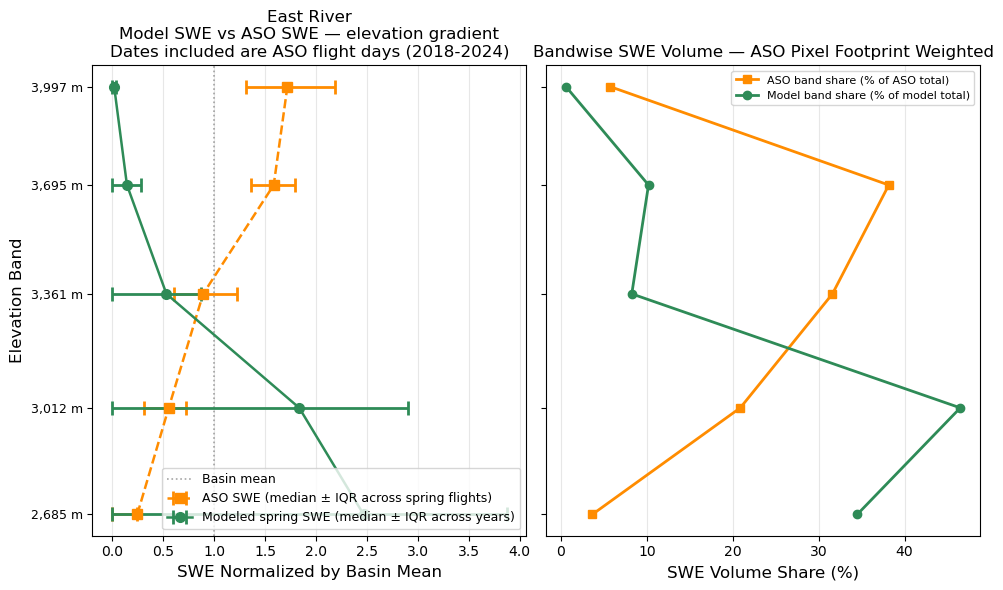

In [81]:
# --- Plot ---
fig, axs = plt.subplots(ncols=2, figsize=(10, max(6, n_hrus * 0.7)), sharey=True)

# Offset the two datasets slightly in y so whiskers don't overlap
dz = 0  # (elevs_sorted[-1] - elevs_sorted[0]) / (n_hrus * 8)

ax = axs[0]
# ASO spring SWE — orange, dashed
ax.errorbar(
    a_med, elevs_sorted - dz,
    xerr=np.array([a_med - a_q25, a_q75 - a_med]),
    fmt="--s", color="darkorange", ecolor="darkorange",
    elinewidth=2, capsize=5, capthick=2,
    markersize=7, linewidth=1.8,
    label="ASO SWE (median ± IQR across spring flights)",
    zorder=4,
)

# Modeled spring SWE — green
ax.errorbar(
    mod_swe_med, elevs_sorted,
    xerr=np.array([mod_swe_med - mod_swe_q25, mod_swe_q75 - mod_swe_med]),
    fmt="-o", color="seagreen", ecolor="seagreen",
    elinewidth=2, capsize=5, capthick=2,
    markersize=7, linewidth=1.8,
    label="Modeled spring SWE (median ± IQR across years)",
    zorder=4,
)

ax.axvline(1.0, color="gray", linestyle=":", linewidth=1.2, alpha=0.7, label="Basin mean")
ax.set_yticks(elevs_sorted)
ax.set_yticklabels([f"{int(e):,} m" for e in elevs_sorted], fontsize=9)
ax.set_xlabel("SWE Normalized by Basin Mean", fontsize=12)
ax.set_ylabel("Elevation Band", fontsize=12)
ax.set_title(
    f"{BASIN.replace('_', ' ')}\n"
    "Model SWE vs ASO SWE — elevation gradient\n"
    "Dates included are ASO flight days (2018-2024)",
    fontsize=12,
)
ax.legend(fontsize=9, loc="lower right")
ax.grid(True, axis="x", alpha=0.3)

# Right panel: volume shares by elevation band (both weighted by ASO pixel footprint per band).
ax = axs[1]
ax.plot(
    aso_band_share_pct, elevs_sorted, "s-", color="darkorange", linewidth=2,
    label="ASO band share (% of ASO total)",
)
ax.plot(
    model_band_share_pct, elevs_sorted, "o-", color="seagreen", linewidth=2,
    label="Model band share (% of model total)",
)

ax.set_xlabel("SWE Volume Share (%)", fontsize=12)
ax.set_title("Bandwise SWE Volume — ASO Pixel Footprint Weighted", fontsize=12)
ax.grid(True, axis="x", alpha=0.3)
ax.legend(fontsize=8, loc="best")

plt.tight_layout()
plt.show()
fig.savefig(f"/scratch/dlhogan/ess-project-data/domain_{BASIN}_distributed_elevTPI/plots/model_v_aso_swe{BASIN}.png", dpi=300)

In [36]:
# trial_params_path = "/scratch/dlhogan/ess-project-data/domain_East_River_distributed/simulations/baseline_longterm_20260426_115838/settings/trialParams.nc"
# new_frozen_precip = np.array([0.07661394, 0.17808464, 0.43541797, 1.40311718, 2.33], dtype=float)*0.95

# # Load into memory first so the source file can be safely overwritten.
# with xr.open_dataset(trial_params_path) as ds:
#     trial_params = ds.load()

# if "frozenPrecipMultip" not in trial_params:
#     raise KeyError("frozenPrecipMultip not found in trialParams.nc")

# target = trial_params["frozenPrecipMultip"]
# if target.size != new_frozen_precip.size:
#     raise ValueError(
#         f"Size mismatch for frozenPrecipMultip: file has {target.size}, new values have {new_frozen_precip.size}"
#     )

# trial_params["frozenPrecipMultip"].values = new_frozen_precip.reshape(target.shape)
# trial_params.to_netcdf(trial_params_path+"_new", mode="w")
# print("Updated frozenPrecipMultip and wrote changes to trialParams.nc")

In [37]:
# save swe_ds 
# swe_ds.to_netcdf(f"/scratch/dlhogan/ess-project-data/geospatial_data/swe_topography_merged.nc")
# save swe flight averages 

In [38]:
# # save tpi class to tif file 
# TPI_PATH = Path(f"/scratch/dlhogan/ess-project-data/domain_{BASIN}_distributed_elev/attributes/tpi")

# # Fill all non-finite cells explicitly, then cast after the mask is clean.
# tpi1000_class_filled = xr.where(np.isfinite(tpi1000_class), tpi1000_class, -9999)
# tpi1000_class_filled = tpi1000_class_filled.round().astype(np.int16)
# tpi1000_class_filled = tpi1000_class_filled.rio.write_nodata(-9999, inplace=False)

# tpi1000_class_filled.rio.to_raster(TPI_PATH / "tpi1000_class.tif", dtype=np.int16, nodata=-9999)

## Snow Heterogeneity

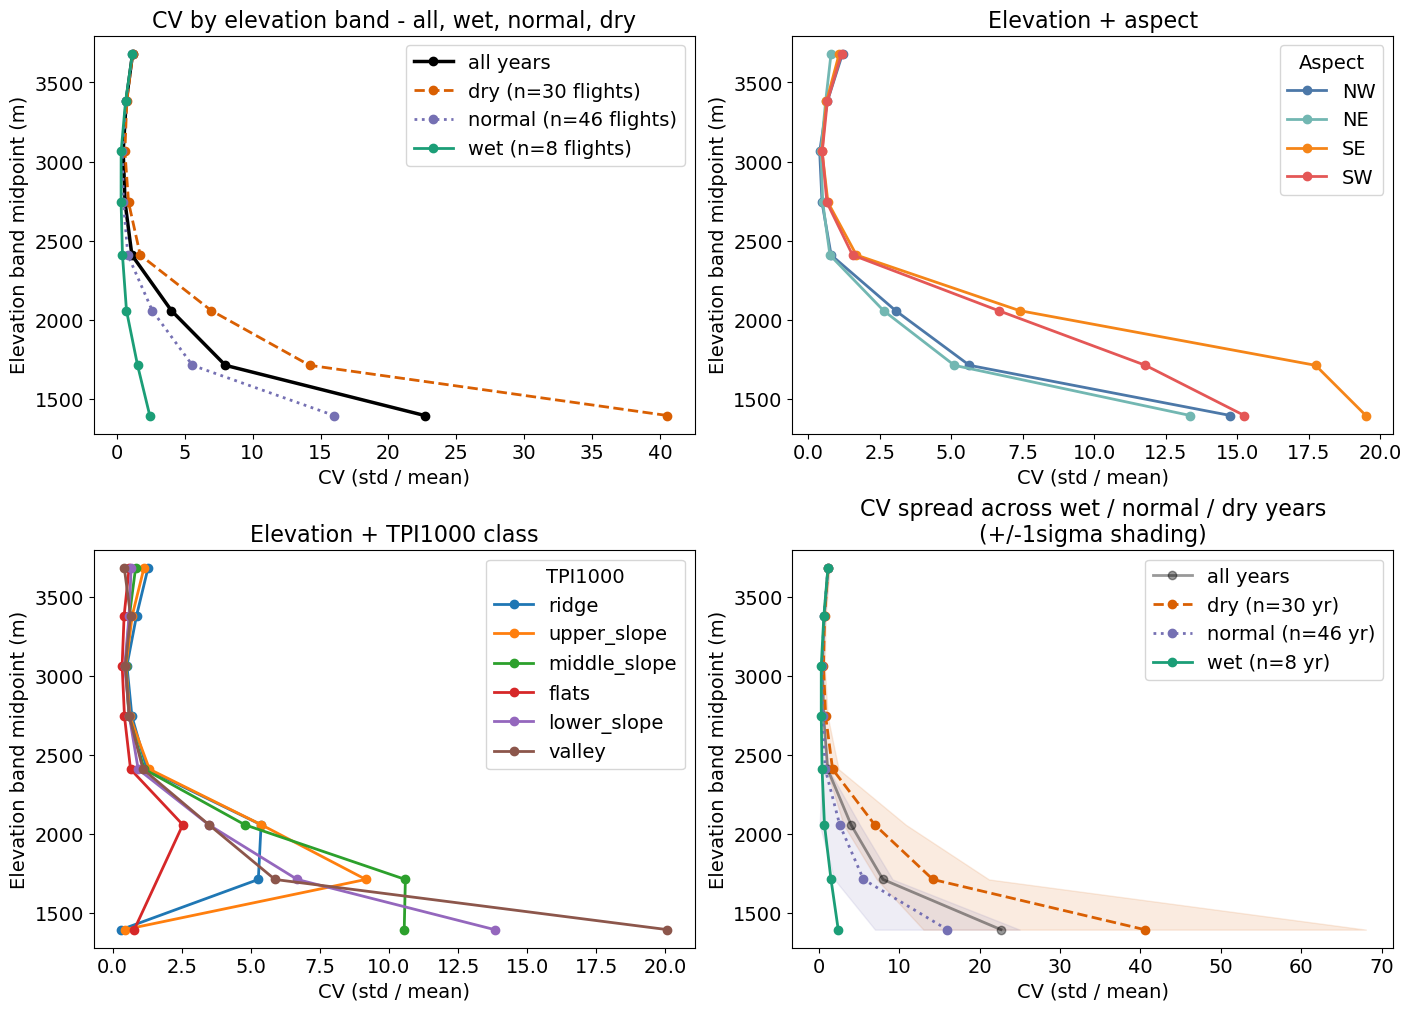

In [ ]:
# Dashboard of heterogeneity figures.
fig, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)

GROUP_COLORS = {"dry": "#D95F02", "normal": "#7570B3", "wet": "#1B9E77"}
GROUP_LS     = {"dry": "--",      "normal": ":",        "wet": "-"}
MIN_FS = 14
TITLE_FS = 16

# Panel A: Elevation bands only (all years + wet/normal/dry overlays).
ax = axes[0, 0]
df_all = cv_elev_summary.sort_values("band_mid_m")
ax.plot(df_all["cv_mean"], df_all["band_mid_m"],  color="black", marker="o",
        linewidth=2.5, label="all years")

for grp, gdf in cv_elev_wetdry_summary.groupby("flow_group", observed=True):
    gdf = gdf.sort_values("band_mid_m")
    n = int(gdf["n_years"].sum())
    ax.plot(
        gdf["cv_mean"], gdf["band_mid_m"],
        marker="o", linewidth=2, linestyle=GROUP_LS.get(grp, "-"),
        color=GROUP_COLORS.get(grp, "#999999"),
        label=f"{grp} (n={n} flights)",
    )
ax.set_title("CV by elevation band - all, wet, normal, dry", fontsize=TITLE_FS)
ax.set_xlabel("CV (std / mean)", fontsize=MIN_FS)
ax.set_ylabel("Elevation band midpoint (m)", fontsize=MIN_FS)
ax.legend(fontsize=MIN_FS, title_fontsize=MIN_FS)

# Panel B: Elevation + aspect.
ax = axes[0, 1]
aspect_order = ["NW", "NE", "SE", "SW"]
aspect_colors = {"NW": "#4C78A8", "NE": "#72B7B2", "SE": "#F58518", "SW": "#E45756"}
for aspect_bin in aspect_order:
    gdf = cv_peak_elev_aspect_summary[cv_peak_elev_aspect_summary["aspect_bin"] == aspect_bin].sort_values("band_mid_m")
    if len(gdf) == 0:
        continue
    ax.plot(
        gdf["cv_mean"], gdf["band_mid_m"],
        marker="o", linewidth=2,
        color=aspect_colors.get(aspect_bin, None),
        label=aspect_bin,
    )
ax.set_title("Elevation + aspect", fontsize=TITLE_FS)
ax.set_xlabel("CV (std / mean)", fontsize=MIN_FS)
ax.set_ylabel("Elevation band midpoint (m)", fontsize=MIN_FS)
ax.legend(title="Aspect", fontsize=MIN_FS, title_fontsize=MIN_FS)

# Panel C: Elevation + TPI1000 class.
ax = axes[1, 0]
tpi_order = ["ridge", "upper_slope", "middle_slope", "flats", "lower_slope", "valley"]
for label in tpi_order:
    gdf = cv_peak_elev_tpi1000_summary[cv_peak_elev_tpi1000_summary["tpi1000_label"] == label].sort_values("band_mid_m")
    if len(gdf) == 0:
        continue
    ax.plot(gdf["cv_mean"], gdf["band_mid_m"], marker="o", linewidth=2, label=label)
ax.set_title("Elevation + TPI1000 class", fontsize=TITLE_FS)
ax.set_xlabel("CV (std / mean)", fontsize=MIN_FS)
ax.set_ylabel("Elevation band midpoint (m)", fontsize=MIN_FS)
ax.legend(title="TPI1000", fontsize=MIN_FS, title_fontsize=MIN_FS)

# Panel D: CV by elevation for each group - wet / normal / dry comparison.
ax = axes[1, 1]

ax.plot(df_all["cv_mean"], df_all["band_mid_m"],  color="black", marker="o",
        linewidth=2, linestyle="-", alpha=0.4, label="all years")
for grp, gdf in cv_elev_wetdry_summary.groupby("flow_group", observed=True):
    gdf = gdf.sort_values("band_mid_m")
    n = int(gdf["n_years"].sum())
    ax.fill_betweenx(
        gdf["band_mid_m"],
        (gdf["cv_mean"] - gdf["cv_std"]).clip(lower=0),
        gdf["cv_mean"] + gdf["cv_std"],
        alpha=0.12, color=GROUP_COLORS.get(grp, "#999999"),
    )
    ax.plot(
        gdf["cv_mean"], gdf["band_mid_m"],
        marker="o", linewidth=2, linestyle=GROUP_LS.get(grp, "-"),
        color=GROUP_COLORS.get(grp, "#999999"),
        label=f"{grp} (n={n} yr)",
    )
ax.set_title("CV spread across wet / normal / dry years\n(+/-1sigma shading)", fontsize=TITLE_FS)
ax.set_ylabel("Elevation band midpoint (m)", fontsize=MIN_FS)
ax.set_xlabel("CV (std / mean)", fontsize=MIN_FS)
ax.legend(fontsize=MIN_FS, title_fontsize=MIN_FS)

for _ax in axes.ravel():
    _ax.tick_params(axis='both', labelsize=MIN_FS)

# selected_flights, cv_elev_summary[["elevation_bins", "cv_mean", "cv_median", "cv_std", "n_years"]], cv_elev_wetdry_summary[["elevation_bins", "flow_group", "cv_mean", "cv_median", "cv_std", "n_years"]]
fig.savefig(f"/scratch/dlhogan/ess-project-data/domain_{BASIN}_distributed_elevTPI/plots/aso_snow_cv_{BASIN}.png", dpi=300)

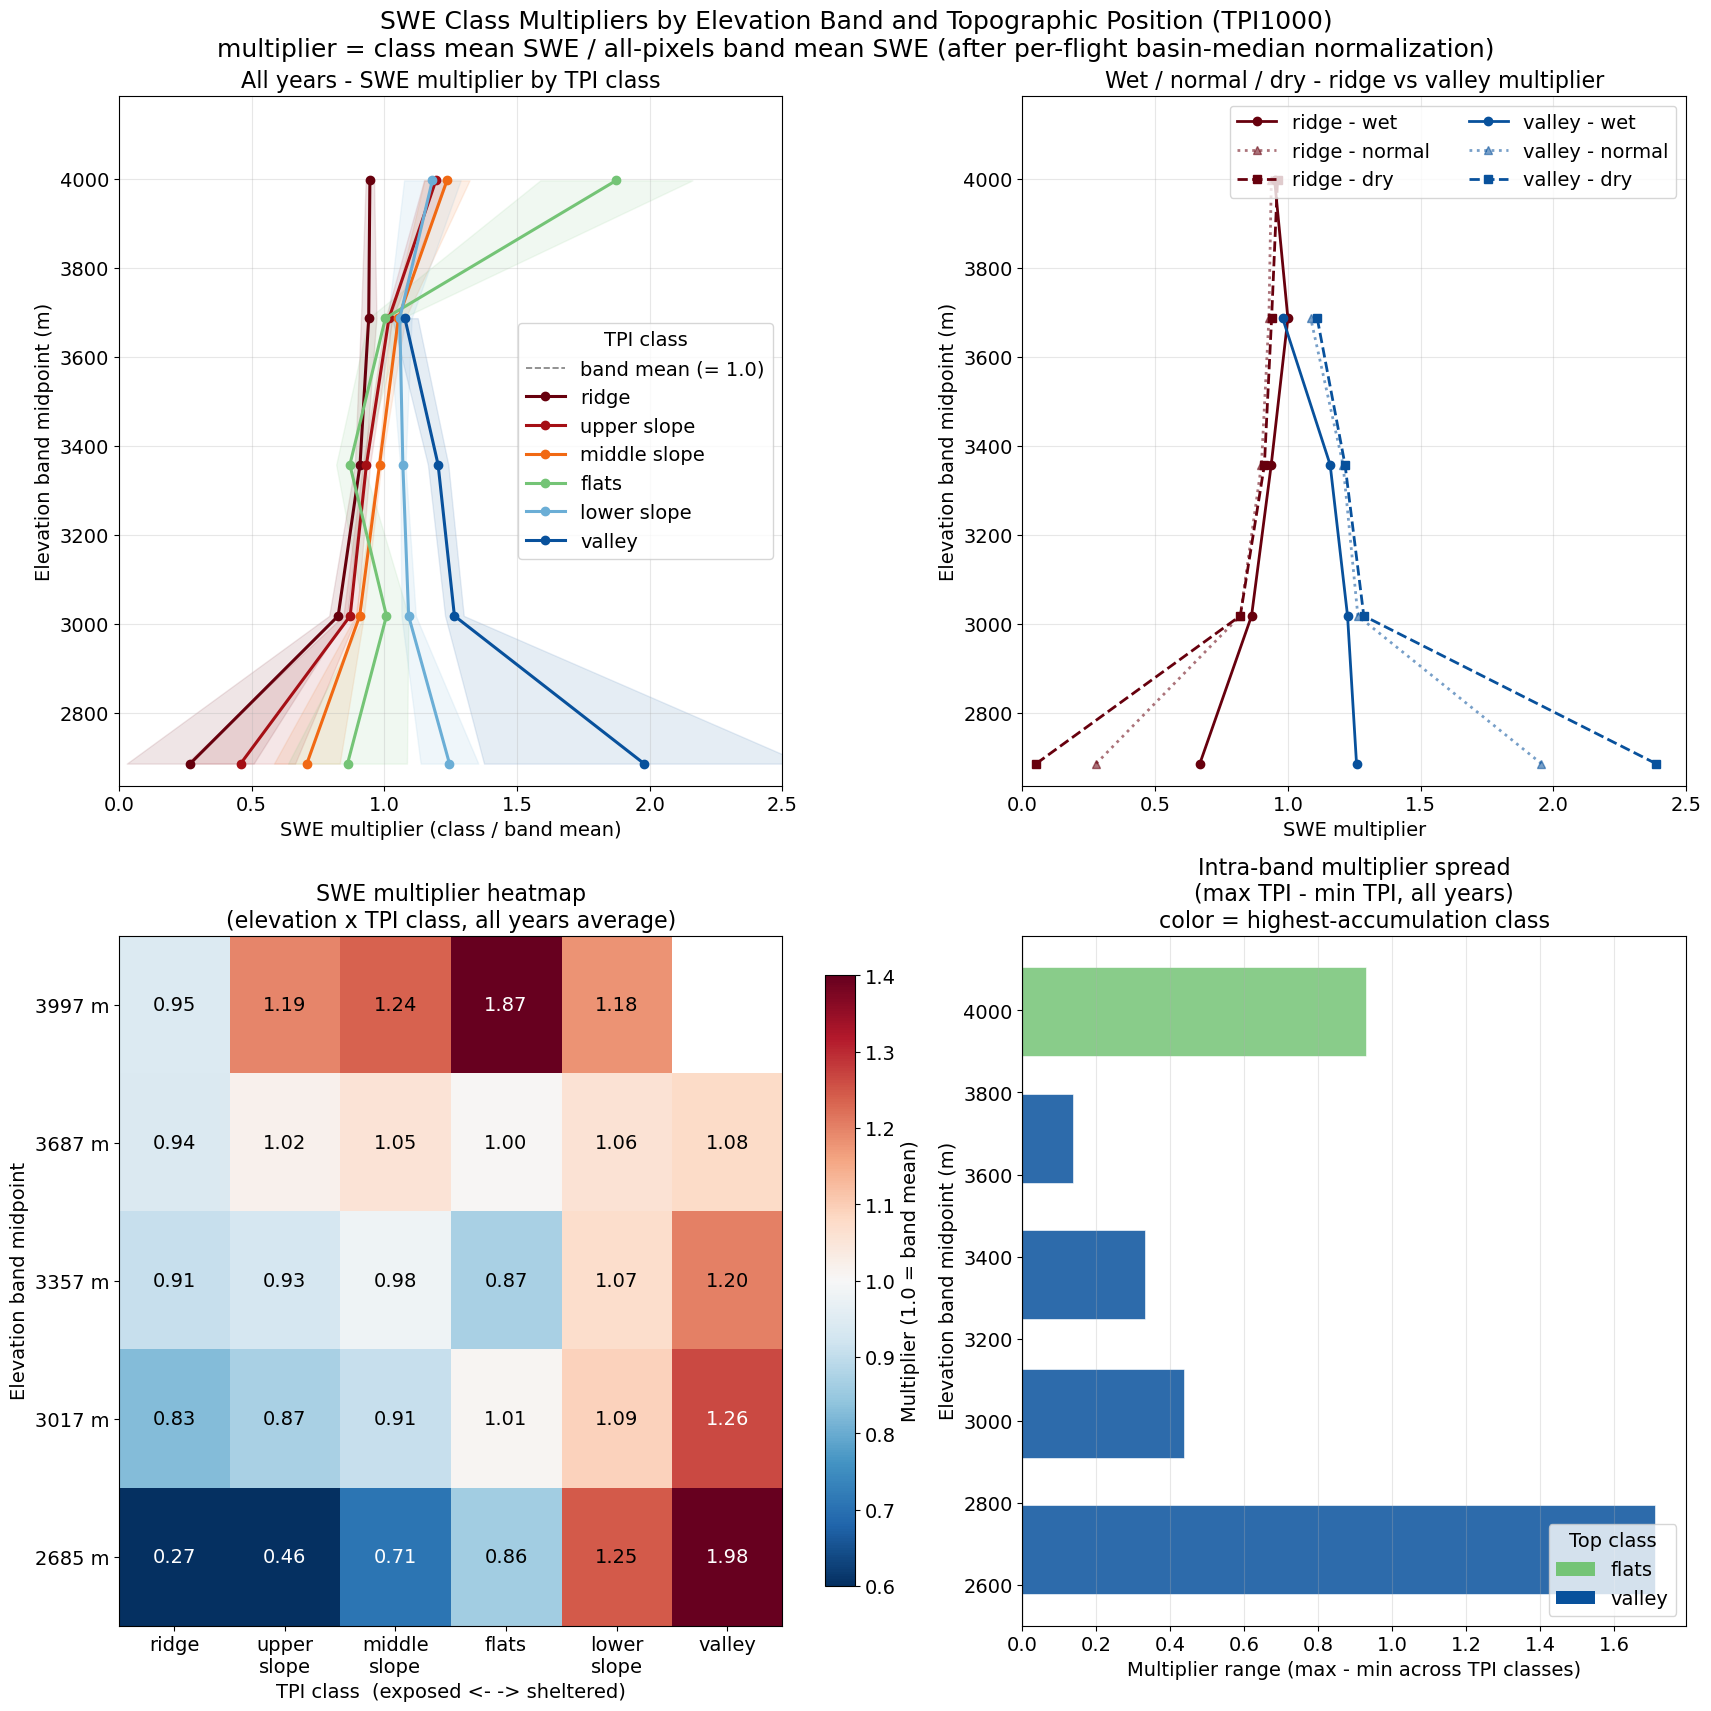


SWE class multipliers (mean SWE basis; per-flight basin-median normalized):
tpi1000_label  ridge  upper_slope  middle_slope  flats  lower_slope  valley
band_mid_m                                                                 
2685.6075      0.269        0.459         0.708  0.862        1.246   1.978
3017.7900      0.826        0.872         0.907  1.008        1.092   1.264
3357.5240      0.909        0.933         0.982  0.870        1.070   1.203
3687.1995      0.941        1.018         1.053  1.004        1.058   1.078
3997.0620      0.946        1.194         1.236  1.874        1.181     NaN

Multiplier by year group (valley):
flow_group    wet  normal    dry
band_mid_m                      
2685.6075   1.258   1.955  2.386
3017.7900   1.225   1.263  1.286
3357.5240   1.159   1.208  1.215
3687.1995   0.980   1.086  1.110

Multiplier by year group (ridge):
flow_group    wet  normal    dry
band_mid_m                      
2685.6075   0.668   0.278  0.052
3017.7900   0.863   0.8

In [ ]:
# =====================================================================
# SWE CLASS MULTIPLIER DASHBOARD
# multiplier = mean_swe_class / mean_swe_band  (all pixels in band)
# Each flight is first normalized by basin-median SWE to reduce
# sensitivity to low/high snow years.
#
# Interpretation: if the band-average SWE is X mm, a pixel assigned to
# this TPI class is expected to hold multiplier x X mm.
# Ridges included so they anchor the low end; values span above/below 1.0.
# =====================================================================

_tpi_df = cv_peak_by_elev_tpi1000.copy()
_tpi_df['_bin_key'] = _tpi_df['elevation_bins'].astype(str)

_elev_mean = cv_peak_by_elev[['time', 'elevation_bins', 'swe_mean']].copy()
_elev_mean['_bin_key'] = _elev_mean['elevation_bins'].astype(str)
_basin_median = (
    swe_peak.median(dim=('y', 'x'), skipna=True)
    .rename('basin_median_swe')
    .to_dataframe()
    .reset_index()
)

mult_df = _tpi_df.merge(
    _elev_mean[['time', '_bin_key', 'swe_mean']].rename(
        columns={'swe_mean': 'swe_mean_band'}
    ),
    on=['time', '_bin_key'],
    how='inner',
)
mult_df = mult_df.merge(_basin_median, on='time', how='left')
mult_df = mult_df[
    (mult_df['swe_mean_band'] > 0) &
    (mult_df['basin_median_swe'] > 0)
] .copy()
mult_df['swe_class_norm'] = mult_df['swe_mean'] / mult_df['basin_median_swe']
mult_df['swe_band_norm'] = mult_df['swe_mean_band'] / mult_df['basin_median_swe']
mult_df['multiplier'] = mult_df['swe_class_norm'] / mult_df['swe_band_norm']

# Summary across all years
mult_summary = (
    mult_df.groupby(['band_mid_m', 'tpi1000_label'], observed=True)
    .agg(
        mult_mean=('multiplier', 'mean'),
        mult_median=('multiplier', 'median'),
        mult_std=('multiplier', 'std'),
        n_obs=('multiplier', 'count'),
        swe_class_mean=('swe_mean', 'mean'),
    )
    .reset_index()
)

# Wet / normal / dry breakdown
mult_byyear = (
    mult_df[mult_df['flow_group'].isin(['dry', 'normal', 'wet'])]
    .groupby(['band_mid_m', 'tpi1000_label', 'flow_group'], observed=True)
    .agg(
        mult_mean=('multiplier', 'mean'),
        mult_std=('multiplier', 'std'),
        n_obs=('multiplier', 'count'),
    )
    .reset_index()
)

# Ordered exposed -> sheltered
TPI_ORDER  = ['ridge', 'upper_slope', 'middle_slope', 'flats', 'lower_slope', 'valley']
TPI_COLORS = {
    'ridge':        '#67000D',
    'upper_slope':  '#A50F15',
    'middle_slope': '#F16913',
    'flats':        '#74C476',
    'lower_slope':  '#6BAED6',
    'valley':       '#08519C',
}
GROUP_COLORS = {'dry': '#D95F02', 'normal': '#7570B3', 'wet': '#1B9E77'}
GROUP_LS     = {'dry': '--',      'normal': ':',        'wet': '-'}
GROUP_MK     = {'dry': 's',       'normal': '^',         'wet': 'o'}

MIN_FS = 14
TITLE_FS = 16
SUPTITLE_FS = 18

fig, axes = plt.subplots(2, 2, figsize=(17, 17), constrained_layout=True)
fig.suptitle(
    'SWE Class Multipliers by Elevation Band and Topographic Position (TPI1000)\n'
    'multiplier = class mean SWE / all-pixels band mean SWE (after per-flight basin-median normalization)',
    fontsize=SUPTITLE_FS,
)

# -- A: Multiplier vs elevation, one line per TPI class (all years) ---------
ax = axes[0, 0]
ax.axhline(1.0, color='black', linewidth=1.2, linestyle='--', alpha=0.5, label='band mean (= 1.0)')
for label in TPI_ORDER:
    gdf = mult_summary[mult_summary['tpi1000_label'] == label].sort_values('band_mid_m')
    if gdf.empty:
        continue
    ax.plot(gdf['mult_mean'], gdf['band_mid_m'],
            marker='o', linewidth=2.2, color=TPI_COLORS[label], label=label.replace('_', ' '))
    ax.fill_betweenx(
        gdf['band_mid_m'],
        (gdf['mult_mean'] - gdf['mult_std']).clip(lower=0),
        gdf['mult_mean'] + gdf['mult_std'],
        alpha=0.10, color=TPI_COLORS[label],
    )
ax.axhline(1.0, color='black', linewidth=1.2, linestyle='--', alpha=0.5)
ax.set_title('All years - SWE multiplier by TPI class', fontsize=TITLE_FS)
ax.set_ylabel('Elevation band midpoint (m)', fontsize=MIN_FS)
ax.set_xlabel('SWE multiplier (class / band mean)', fontsize=MIN_FS)
ax.legend(title='TPI class', fontsize=MIN_FS, title_fontsize=MIN_FS)
ax.grid(True, alpha=0.3)
ax.set_ylim(bottom=gdf['band_mid_m'].min() - 50, top=gdf['band_mid_m'].max() + 500)
ax.set_xlim(0,2.5)

# -- B: Wet / normal / dry - ridge vs valley --------------------------------
ax = axes[0, 1]
ax.axhline(1.0, color='black', linewidth=1.2, linestyle='--', alpha=0.5)
for label in ['ridge', 'valley']:
    for grp in ['wet', 'normal', 'dry']:
        gdf = mult_byyear[
            (mult_byyear['tpi1000_label'] == label) &
            (mult_byyear['flow_group'] == grp)
] .sort_values('band_mid_m')
        if gdf.empty:
            continue
        n = int(gdf['n_obs'].sum())
        ax.plot(
            gdf['mult_mean'], gdf['band_mid_m'],
            marker=GROUP_MK[grp], linewidth=2, linestyle=GROUP_LS[grp],
            color=TPI_COLORS[label],
            alpha=0.55 if grp == 'normal' else 1.0,
            label=f"{label.replace('_', ' ')} - {grp}",
        )
ax.axhline(1.0, color='black', linewidth=1.2, linestyle='--', alpha=0.5)
ax.set_title('Wet / normal / dry - ridge vs valley multiplier', fontsize=TITLE_FS)
ax.set_ylabel('Elevation band midpoint (m)', fontsize=MIN_FS)
ax.set_xlabel('SWE multiplier', fontsize=MIN_FS)
ax.legend(fontsize=MIN_FS, ncol=2)
ax.grid(True, alpha=0.3)
ax.set_ylim(bottom=gdf['band_mid_m'].min() - 50, top=gdf['band_mid_m'].max() + 500)
ax.set_xlim(0,2.5)


# -- C: Heatmap - multiplier by elevation x TPI class -----------------------
ax = axes[1, 0]
_pivot = (
    mult_summary
    .pivot_table(index='band_mid_m', columns='tpi1000_label', values='mult_mean', aggfunc='mean')
    .sort_index(ascending=False)
)
_cols = [c for c in TPI_ORDER if c in _pivot.columns]
_pivot = _pivot[_cols]

im = ax.imshow(
    _pivot.values, aspect='auto',
    cmap='RdBu_r', vmin=0.6, vmax=1.4,
    origin='upper',
)
ax.set_xticks(range(len(_cols)))
ax.set_xticklabels([c.replace('_', '\n') for c in _cols], fontsize=MIN_FS)
ax.set_yticks(range(len(_pivot.index)))
ax.set_yticklabels([f'{int(v)} m' for v in _pivot.index], fontsize=MIN_FS)
ax.set_title('SWE multiplier heatmap\n(elevation x TPI class, all years average)', fontsize=TITLE_FS)
ax.set_xlabel('TPI class  (exposed <- -> sheltered)', fontsize=MIN_FS)
ax.set_ylabel('Elevation band midpoint', fontsize=MIN_FS)
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Multiplier (1.0 = band mean)', fontsize=MIN_FS)
cbar.ax.tick_params(labelsize=MIN_FS)
cbar.ax.axhline(y=(1.0 - 0.6) / (1.4 - 0.6), color='black', linewidth=1.5)

for i in range(_pivot.shape[0]):
    for j in range(_pivot.shape[1]):
        v = _pivot.values[i, j]
        if np.isfinite(v):
            txt_color = 'white' if (v < 0.75 or v > 1.25) else 'black'
            ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=MIN_FS, color=txt_color)

# -- D: Multiplier spread (max - min) by elevation band ---------------------
ax = axes[1, 1]
_range_rows = []
for _band, _gdf in mult_summary.groupby('band_mid_m', observed=True):
    if _gdf.empty:
        continue
    _range_rows.append({
        'band_mid_m': _band,
        'mult_max': _gdf['mult_mean'].max(),
        'mult_min': _gdf['mult_mean'].min(),
        'top_class': _gdf.loc[_gdf['mult_mean'].idxmax(), 'tpi1000_label'],
    })
_range = (
    pd.DataFrame(_range_rows)
    .assign(mult_range=lambda d: d['mult_max'] - d['mult_min'])
    .sort_values('band_mid_m')
)
# Bar height: 70% of the smallest gap between adjacent bands
_sorted_bands = np.sort(_range['band_mid_m'].values)
_min_gap = float(np.min(np.diff(_sorted_bands))) if len(_sorted_bands) > 1 else 200.0
_bar_height = max(15.0, 0.70 * _min_gap)

_colors = [TPI_COLORS.get(c, '#6A51A3') for c in _range['top_class']]
ax.barh(
    _range['band_mid_m'], _range['mult_range'],
    height=_bar_height, color=_colors, alpha=0.85, edgecolor='white', linewidth=0.5,
)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Intra-band multiplier spread\n(max TPI - min TPI, all years)\ncolor = highest-accumulation class', fontsize=TITLE_FS)
ax.set_xlabel('Multiplier range (max - min across TPI classes)', fontsize=MIN_FS)
ax.set_ylabel('Elevation band midpoint (m)', fontsize=MIN_FS)
ax.grid(True, alpha=0.3, axis='x')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=TPI_COLORS[c], label=c.replace('_', ' '))
                   for c in TPI_ORDER if c in _range['top_class'].values]
ax.legend(handles=legend_elements, title='Top class', fontsize=MIN_FS, title_fontsize=MIN_FS, loc='lower right')

for _ax in axes.ravel():
    _ax.tick_params(axis='both', labelsize=MIN_FS)

plt.show()

# Print multiplier lookup table
print('\nSWE class multipliers (mean SWE basis; per-flight basin-median normalized):')
_tbl = (
    mult_summary
    .pivot_table(index='band_mid_m', columns='tpi1000_label', values='mult_mean', aggfunc='mean')
    [_cols]
    .sort_index()
    .round(3)
)
print(_tbl.to_string())

# Per-group pivot for stability check
print('\nMultiplier by year group (valley):')
_valley = mult_byyear[mult_byyear['tpi1000_label'] == 'valley'].pivot_table(
    index='band_mid_m', columns='flow_group', values='mult_mean'
)[['wet', 'normal', 'dry']].sort_index().round(3)
print(_valley.to_string())

print('\nMultiplier by year group (ridge):')
_ridge = mult_byyear[mult_byyear['tpi1000_label'] == 'ridge'].pivot_table(
    index='band_mid_m', columns='flow_group', values='mult_mean'
)[['wet', 'normal', 'dry']].sort_index().round(3)
print(_ridge.to_string())
fig.savefig(f"/scratch/dlhogan/ess-project-data/domain_{BASIN}_distributed_elevTPI/plots/aso_TPI_multipliers_{BASIN}.png", dpi=300)

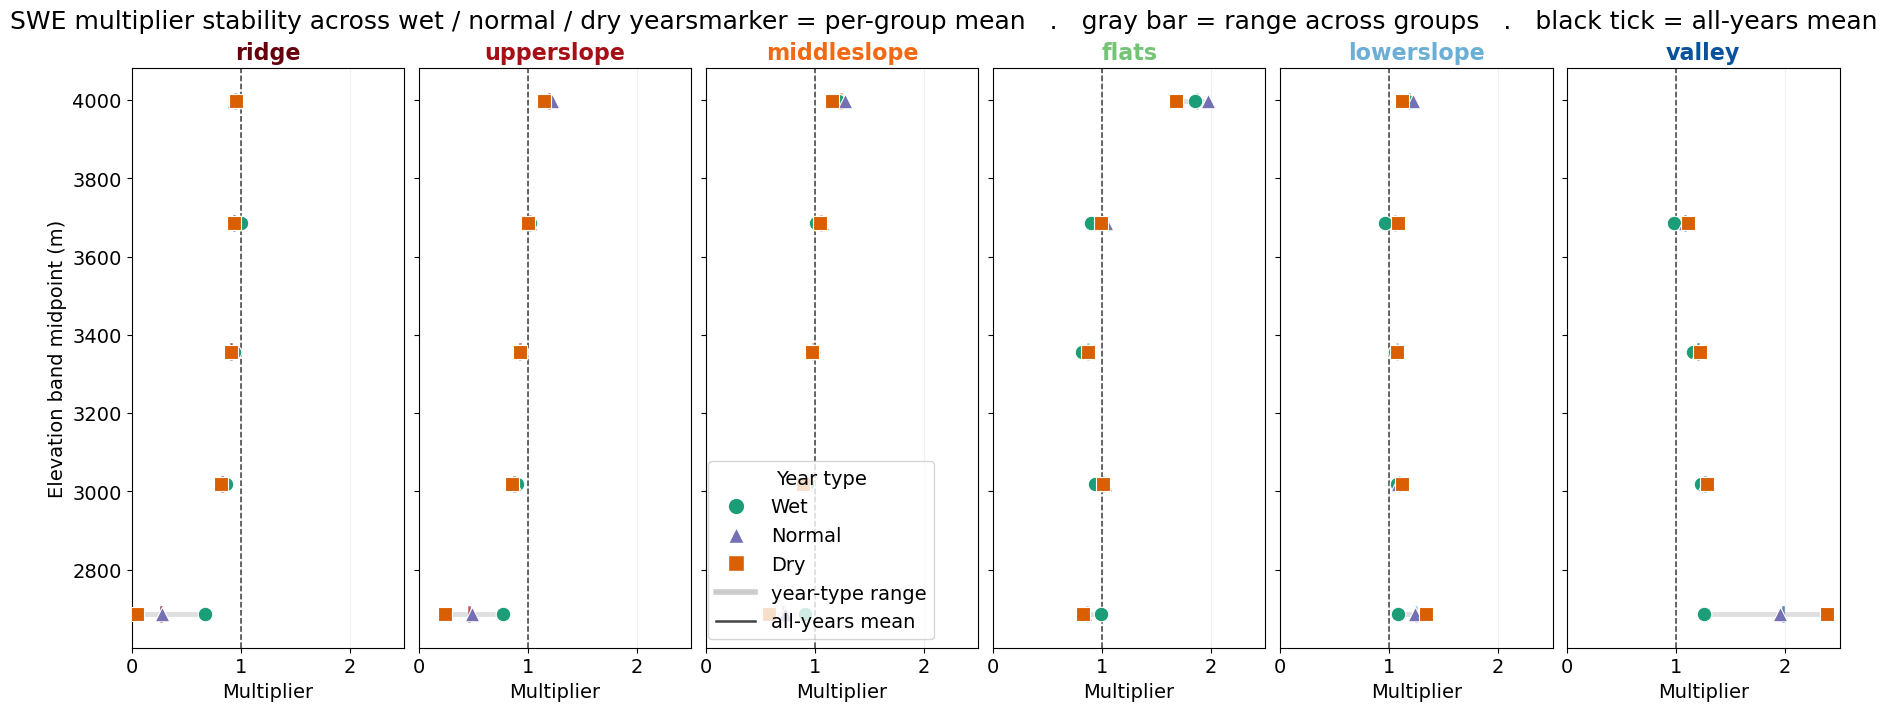

Multiplier range (wet-normal-dry spread) per elevation x TPI class:
tpi1000_label  ridge  upper_slope  middle_slope  flats  lower_slope  valley
band_mid_m                                                                 
2685.6075      0.616        0.529         0.333  0.166        0.263   1.128
3017.7900      0.043        0.048         0.033  0.091        0.052   0.061
3357.5240      0.037        0.011         0.009  0.069        0.015   0.056
3687.1995      0.071        0.019         0.060  0.134        0.120   0.130
3997.0620      0.023        0.070         0.119  0.299        0.103     NaN


In [ ]:
# =====================================================================
# MULTIPLIER STABILITY DASHBOARD
# One panel per TPI class; y = elevation, x = multiplier value.
# Each elevation level shows three markers (wet / normal / dry) connected
# by a gray range line - short lines mean the multiplier is stable across
# year types; long lines mean it is sensitive to water-year conditions.
# =====================================================================

TPI_ORDER_STAB  = ['ridge', 'upper_slope', 'middle_slope', 'flats', 'lower_slope', 'valley']
TPI_COLORS_STAB = {
    'ridge':        '#67000D',
    'upper_slope':  '#A50F15',
    'middle_slope': '#F16913',
    'flats':        '#74C476',
    'lower_slope':  '#6BAED6',
    'valley':       '#08519C',
}
GROUP_COLORS_STAB = {'wet': '#1B9E77', 'normal': '#7570B3', 'dry': '#D95F02'}
GROUP_MK_STAB     = {'wet': 'o',       'normal': '^',       'dry': 's'}
MIN_FS = 14
TITLE_FS = 16
SUPTITLE_FS = 18

# Also pull the all-years mean for reference dots
_all_summary = mult_summary['tpi1000_label'].unique()

n_tpi = len(TPI_ORDER_STAB)
fig, axes = plt.subplots(1, n_tpi, figsize=(18, 7), sharey=True, constrained_layout=True)
fig.suptitle(
    'SWE multiplier stability across wet / normal / dry years'
    'marker = per-group mean   .   gray bar = range across groups   .   black tick = all-years mean',
    fontsize=SUPTITLE_FS,
)

for ax, tpi_label in zip(axes, TPI_ORDER_STAB):
    tpi_color = TPI_COLORS_STAB.get(tpi_label, 'black')

    sub = mult_byyear[mult_byyear['tpi1000_label'] == tpi_label].copy()
    sub_all = mult_summary[mult_summary['tpi1000_label'] == tpi_label].copy()

    for band_m in sorted(sub['band_mid_m'].unique()):
        row = sub[sub['band_mid_m'] == band_m].set_index('flow_group')['mult_mean']
        present = [g for g in ['wet', 'normal', 'dry'] if g in row.index]

        if len(present) >= 2:
            ax.plot(
                [row[present].min(), row[present].max()],
                [band_m, band_m],
                color='gray', lw=3.5, alpha=0.25, solid_capstyle='round', zorder=1,
            )

        for grp in present:
            ax.scatter(
                row[grp], band_m,
                color=GROUP_COLORS_STAB[grp], marker=GROUP_MK_STAB[grp],
                s=110, zorder=3, linewidths=0.8, edgecolors='white',
            )

        # All-years mean as a thin vertical tick
        all_row = sub_all[sub_all['band_mid_m'] == band_m]
        if not all_row.empty:
            m = float(all_row['mult_mean'].iloc[0])
            ax.plot([m, m], [band_m - 18, band_m + 18],
                    color=tpi_color, lw=1.8, alpha=0.7, zorder=2)

    ax.set_title(tpi_label.replace('_', ''), fontsize=TITLE_FS,
                 color=tpi_color, fontweight='bold')
    ax.set_xlabel('Multiplier', fontsize=MIN_FS)
    ax.set_xlim(0.0, 2.5)
    ax.grid(True, alpha=0.20, axis='x')
    ax.axvline(1.0, color='black', lw=1.1, ls='--', alpha=0.75)
    ax.tick_params(axis='both', labelsize=MIN_FS)

axes[0].set_ylabel('Elevation band midpoint (m)', fontsize=MIN_FS)

# Legend
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
handles = [
    Line2D([0], [0], marker=GROUP_MK_STAB[g], color='w',
           markerfacecolor=GROUP_COLORS_STAB[g], markersize=12,
           markeredgecolor='white', label=g.capitalize())
    for g in ['wet', 'normal', 'dry']
]
handles += [
    Line2D([0], [0], color='gray', lw=4, alpha=0.4, label='year-type range'),
    Line2D([0], [0], color='#444444', lw=1.8, label='all-years mean'),
]
fig.legend(handles=handles, title='Year type', loc='lower right',
           fontsize=MIN_FS, title_fontsize=MIN_FS, frameon=True, bbox_to_anchor=(0.5, 0.08))

plt.show()

# Print range table: max(wet,normal,dry) - min(wet,normal,dry) per band x class
print('Multiplier range (wet-normal-dry spread) per elevation x TPI class:')
_stab = (
    mult_byyear.groupby(['band_mid_m', 'tpi1000_label'], observed=True)['mult_mean']
    .agg(spread=lambda s: s.max() - s.min())
    .reset_index()
    .pivot_table(index='band_mid_m', columns='tpi1000_label', values='spread', aggfunc='mean')
)
_stab_cols = [c for c in TPI_ORDER_STAB if c in _stab.columns]
print(_stab[_stab_cols].sort_index().round(3).to_string())
fig.savefig(f"/scratch/dlhogan/ess-project-data/domain_{BASIN}_distributed_elevTPI/plots/aso_multiplier_stability_{BASIN}.png", dpi=300)


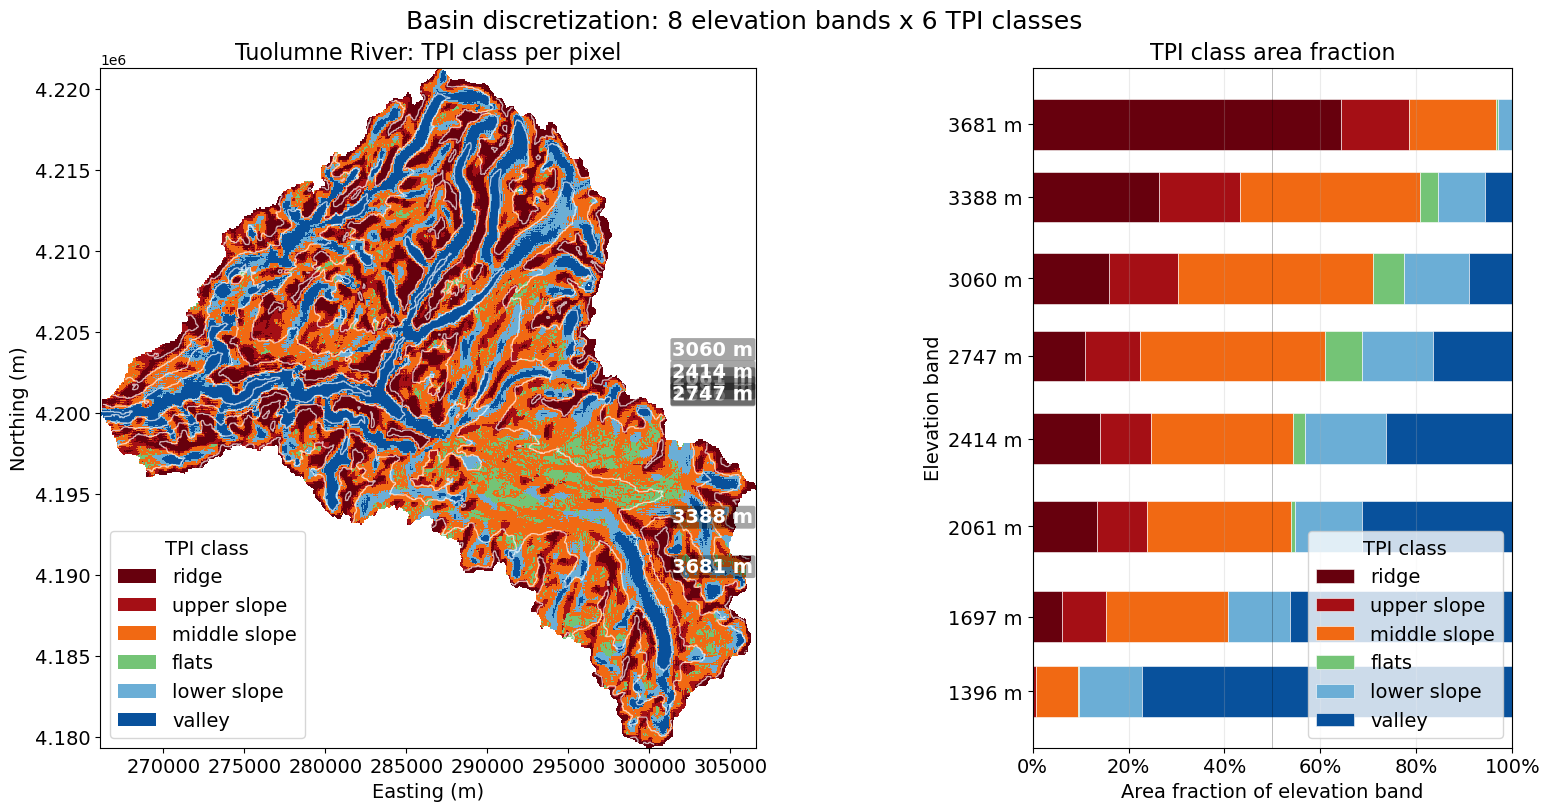

In [39]:
# =====================================================================
# BASIN DISCRETIZATION MAP
# Spatial map of Tuolumne basin pixels colored by TPI class,
# with HRU elevation band boundaries overlaid as contours.
# Right panel: area fraction of each TPI class per elevation band.
# Elevation bands that are < 100 m apart are lumped in the bar chart only.
# =====================================================================
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from matplotlib.ticker import PercentFormatter

TPI_ORDER_MAP  = ['ridge', 'upper_slope', 'middle_slope', 'flats', 'lower_slope', 'valley']
TPI_LABELS_MAP = {
    'ridge':        1, 'upper_slope':  2, 'middle_slope': 3,
    'flats':        4, 'lower_slope':  5, 'valley':       6,
}
TPI_COLORS_MAP = {
    'ridge':        '#67000D', 'upper_slope':  '#A50F15',
    'middle_slope': '#F16913', 'flats':        '#74C476',
    'lower_slope':  '#6BAED6', 'valley':       '#08519C',
}
MIN_FS = 14
TITLE_FS = 16
SUPTITLE_FS = 18

# --- Pixel arrays ---
elev_arr = swe_ds['elevation'].values
tpi_arr  = swe_ds['tpi1000_class'].values
x_coords = swe_ds['elevation'].x.values
y_coords = swe_ds['elevation'].y.values

band_idx_raw = np.digitize(elev_arr, elev_bins) - 1
band_idx = np.where(
    np.isfinite(elev_arr) & (band_idx_raw >= 0) & (band_idx_raw < len(_centroids)),
    band_idx_raw.astype(float), np.nan
)

# --- RGBA image for spatial map ---
tpi_rgba = np.zeros((*tpi_arr.shape, 4), dtype=float)
for label, cls_id in TPI_LABELS_MAP.items():
    mask = (tpi_arr == cls_id) & np.isfinite(elev_arr)
    rgb  = mcolors.to_rgb(TPI_COLORS_MAP[label])
    tpi_rgba[mask, :3] = rgb
    tpi_rgba[mask,  3] = 1.0

dx = float(x_coords[1] - x_coords[0])
dy = float(y_coords[1] - y_coords[0])
extent_map = [
    x_coords[0] - 0.5*dx, x_coords[-1] + 0.5*dx,
    y_coords[-1] + 0.5*dy, y_coords[0]  - 0.5*dy,
]

# --- Area fraction per (full) elevation band ---
area_rows = []
for bi, cen in enumerate(_centroids):
    band_mask = (band_idx == bi)
    total_px  = int(np.sum(band_mask & np.isfinite(tpi_arr)))
    for label, cls_id in TPI_LABELS_MAP.items():
        cls_px = int(np.sum(band_mask & (tpi_arr == cls_id)))
        area_rows.append({
            'band_idx': bi, 'centroid_m': cen, 'tpi_label': label,
            'n_pixels': cls_px, 'total_px': total_px,
            'frac': cls_px / total_px if total_px > 0 else 0.0,
        })
area_df = pd.DataFrame(area_rows)

# --- Lump narrow bands (< 100 m apart) for bar chart only ---
_LUMP_THRESH_M = 100.0
_sorted_cens = sorted(area_df['centroid_m'].unique())
_lump_map   = {}
_bar_labels  = {}   # lumped centroid -> display label
i = 0
while i < len(_sorted_cens):
    if (i < len(_sorted_cens) - 1
            and (_sorted_cens[i+1] - _sorted_cens[i]) < _LUMP_THRESH_M):
        merged = (_sorted_cens[i] + _sorted_cens[i+1]) / 2.0
        _lump_map[_sorted_cens[i]]   = merged
        _lump_map[_sorted_cens[i+1]] = merged
        _bar_labels[merged] = f'{int(_sorted_cens[i])}-{int(_sorted_cens[i+1])} m (lumped)'
        i += 2
    else:
        _lump_map[_sorted_cens[i]] = _sorted_cens[i]
        _bar_labels[_sorted_cens[i]] = f'{int(_sorted_cens[i])} m'
        i += 1

area_df['centroid_bar'] = area_df['centroid_m'].map(_lump_map)
area_bar = (
    area_df.groupby(['centroid_bar', 'tpi_label'], observed=True)
    .agg(n_pixels=('n_pixels', 'sum'), total_px=('total_px', 'sum'))
    .reset_index()
)
area_bar['frac'] = area_bar['n_pixels'] / area_bar['total_px'].clip(lower=1)
bar_cens = sorted(area_bar['centroid_bar'].unique())

# Bar height: 70% of smallest gap between lumped centroids
_bar_gaps = np.diff(bar_cens) if len(bar_cens) > 1 else np.array([200.0])
_bar_h    = max(30.0, 0.70 * float(_bar_gaps.min()))

# --- Figure ---
fig = plt.figure(figsize=(16, 8), constrained_layout=True)
gs  = fig.add_gridspec(1, 2, width_ratios=[2, 1])
ax_map = fig.add_subplot(gs[0])
ax_bar = fig.add_subplot(gs[1])

# -- Panel A: spatial TPI map ------------------------------------------------
ax_map.imshow(tpi_rgba, aspect='equal', origin='upper',
              extent=extent_map, interpolation='nearest')
ax_map.contour(x_coords, y_coords, elev_arr,
               levels=elev_bins, colors='white', linewidths=0.9, alpha=0.7)

for bi, cen in enumerate(_centroids):
    mask = (band_idx == bi) & np.isfinite(tpi_arr)
    if not np.any(mask):
        continue
    ys, _ = np.where(mask)
    mid_y = int(np.median(ys))
    ax_map.text(
        x_coords[-1] - abs(dx)*3, y_coords[mid_y],
        f'{int(cen)} m', fontsize=MIN_FS, color='white', va='center', ha='right',
        fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.1', fc='black', alpha=0.35, lw=0),
    )

ax_map.set_title(f'{BASIN.replace("_", " ")}: TPI class per pixel', fontsize=TITLE_FS)
ax_map.set_xlabel('Easting (m)', fontsize=MIN_FS)
ax_map.set_ylabel('Northing (m)', fontsize=MIN_FS)
ax_map.tick_params(labelsize=MIN_FS)
ax_map.legend(
    handles=[mpatches.Patch(facecolor=TPI_COLORS_MAP[l], label=l.replace('_', ' '))
             for l in TPI_ORDER_MAP],
    title='TPI class', fontsize=MIN_FS, title_fontsize=MIN_FS,
    loc='lower left', framealpha=0.8,
)

# -- Panel B: stacked area fraction (lumped bands) ---------------------------
cumulative = np.zeros(len(bar_cens))
for label in TPI_ORDER_MAP:
    fracs = [
        float(area_bar[(area_bar['centroid_bar'] == c) &
                        (area_bar['tpi_label']    == label)]['frac'].values[0])
        if len(area_bar[(area_bar['centroid_bar'] == c) & (area_bar['tpi_label'] == label)]) > 0
        else 0.0
        for c in bar_cens
    ]
    ax_bar.barh(bar_cens, fracs, left=cumulative, height=_bar_h,
                color=TPI_COLORS_MAP[label], label=label.replace('_', ' '),
                edgecolor='white', linewidth=0.4)
    cumulative = cumulative + np.array(fracs)

ax_bar.set_yticks(bar_cens)
ax_bar.set_yticklabels([_bar_labels[c] for c in bar_cens], fontsize=MIN_FS)
ax_bar.set_xlim(0, 1)
ax_bar.xaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))
ax_bar.set_xlabel('Area fraction of elevation band', fontsize=MIN_FS)
ax_bar.set_ylabel('Elevation band', fontsize=MIN_FS)
ax_bar.set_title('TPI class area fraction', fontsize=TITLE_FS)
ax_bar.tick_params(axis='both', labelsize=MIN_FS)
ax_bar.legend(title='TPI class', fontsize=MIN_FS, title_fontsize=MIN_FS,
              loc='lower right', framealpha=0.8)
ax_bar.grid(True, axis='x', alpha=0.25)
ax_bar.axvline(0.5, color='black', lw=0.6, alpha=0.3)

fig.suptitle(
    f'Basin discretization: {len(_centroids)} elevation bands x 6 TPI classes',
    fontsize=SUPTITLE_FS,
)
plt.show()
fig.savefig(f"/scratch/dlhogan/ess-project-data/domain_{BASIN}_distributed_elevTPI/plots/basin_discretization_map_{BASIN}.png")

In [14]:
# TPI class geodatrafraome
tpi_gdf = gpd.read_file(f"/scratch/dlhogan/ess-project-data/domain_{BASIN}_distributed_elevTPI/shapefiles/catchment/{BASIN}_distributed_elevTPI_HRUs_elevation_tpi.shp").to_crs(local_crs[BASIN])  
elev_gdf = gpd.read_file(f"/scratch/dlhogan/ess-project-data/domain_{BASIN}_distributed_elevTPI/shapefiles/catchment/{BASIN}_distributed_HRUs_elevation.shp").to_crs(local_crs[BASIN])
mean_swe = swe_ds['swe'].mean(dim=['time'], skipna=True)

In [16]:
# Map each HRU directly to mult_summary using nearest elevation centroid + TPI label
_band_mids = np.sort(mult_summary['band_mid_m'].unique())
_tpi_label_map = {1:'ridge', 2:'upper_slope', 3:'middle_slope', 4:'flats', 5:'lower_slope', 6:'valley'}

tpi_mean_swe = tpi_gdf[['HRU_ID', 'elevClass', 'tpiClass', 'elev_mean']].copy()
tpi_mean_swe['band_mid_m']    = tpi_mean_swe['elev_mean'].apply(
    lambda e: float(_band_mids[np.argmin(np.abs(_band_mids - e))])
)
tpi_mean_swe['tpi_class'] = tpi_mean_swe['tpiClass'].map(_tpi_label_map)
tpi_mean_swe = tpi_mean_swe.merge(
    mult_summary[['band_mid_m', 'tpi1000_label', 'mult_mean']].rename(columns={'tpi1000_label': 'tpi_class', 'mult_mean': 'multiplier'}),
    on=['band_mid_m', 'tpi_class'],
    how='left',
)


NameError: name 'mult_summary' is not defined

/tmp/ipykernel_1040040/1010352996.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=tpi_mean_swe, x='tpi_class', y='multiplier', palette=TPI_COLORS_MAP)


Text(0, 0.5, 'SWE Multiplier (TPI mean / Band mean)')

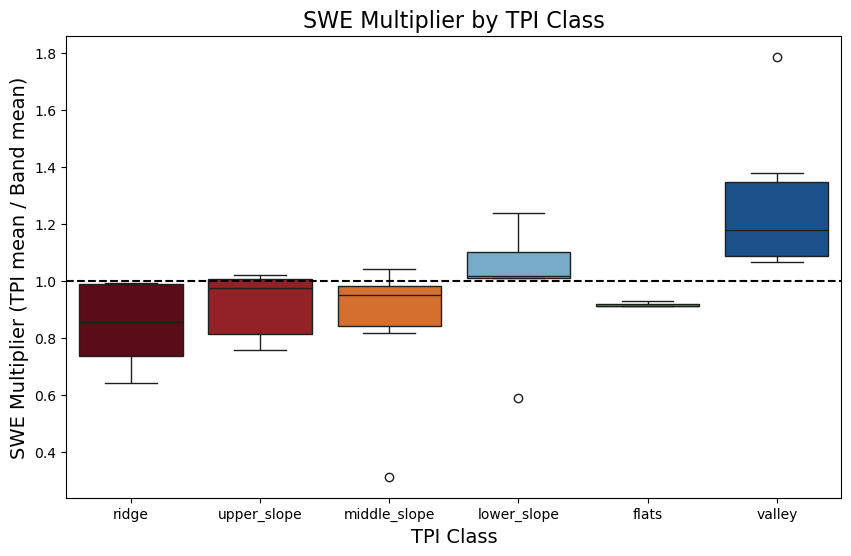

In [308]:
import seaborn as sns
# plot the multiplier by tpi class
plt.figure(figsize=(10, 6))
sns.boxplot(data=tpi_mean_swe, x='tpi_class', y='multiplier', palette=TPI_COLORS_MAP)
plt.axhline(1.0, color='black', linestyle='--', label='Band mean (1.0)')
plt.title('SWE Multiplier by TPI Class', fontsize=16)
plt.xlabel('TPI Class', fontsize=14)
plt.ylabel('SWE Multiplier (TPI mean / Band mean)', fontsize=14)

In [309]:
tpi_mean_swe.to_csv(f"/scratch/dlhogan/ess-project-data/domain_{BASIN}_distributed_elevTPI/settings/SUMMA/tpi_swe_multipliers.csv", index=False)

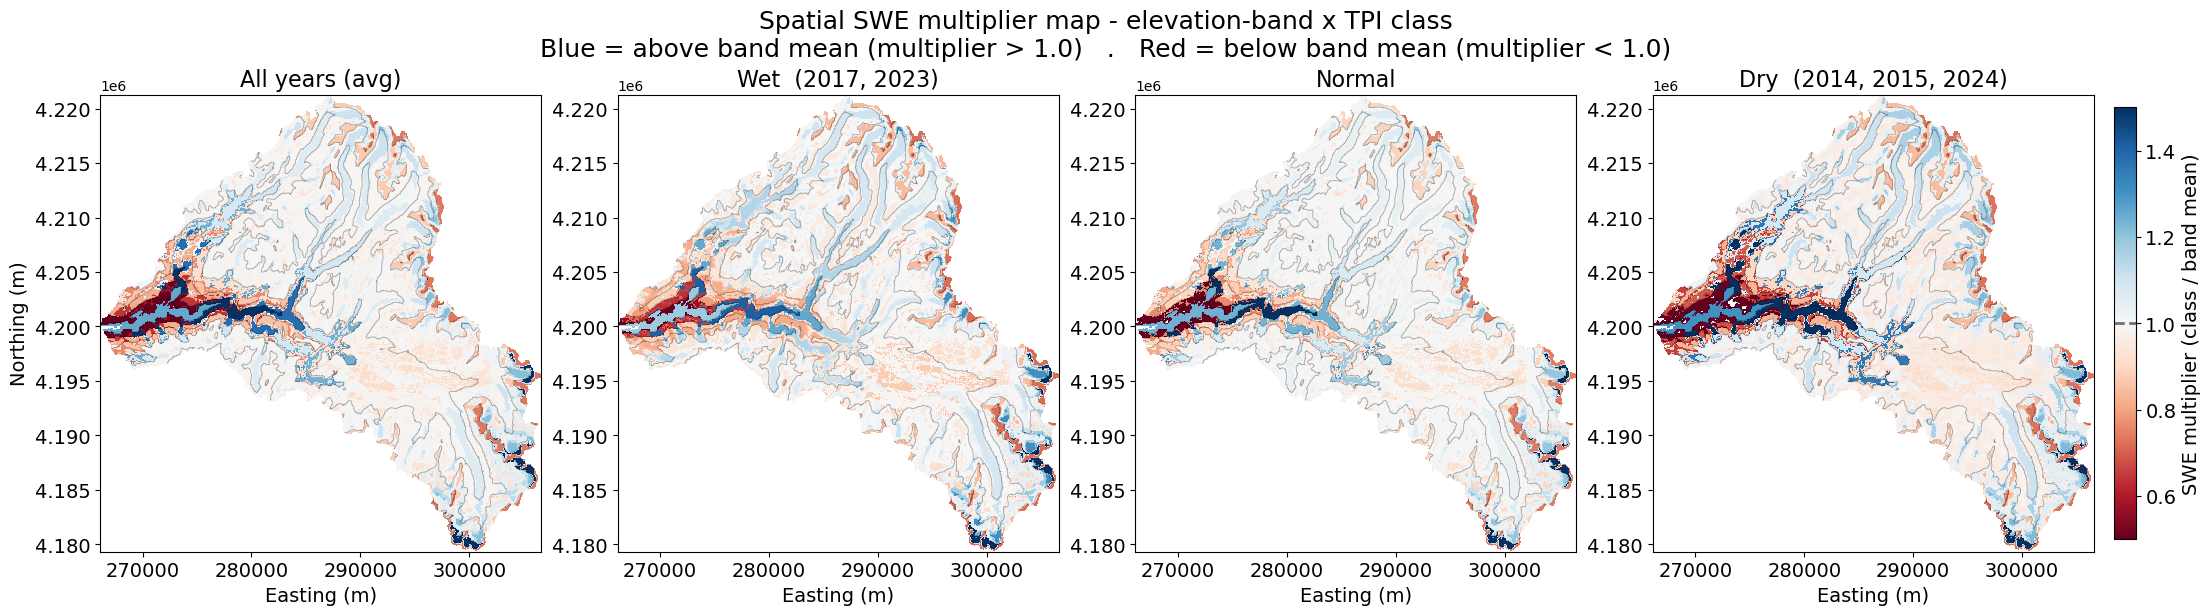

All-years mean multiplier per (elevation band, TPI class):
tpi1000_label  ridge  upper_slope  middle_slope  flats  lower_slope  valley
band_mid_m                                                                 
1396.1215      0.276        0.396         0.250  0.225        0.252   1.255
1713.1345      0.237        0.293         0.314    NaN        0.588   1.788
2058.7085      0.643        0.816         0.817  1.050        1.019   1.381
2409.6200      0.857        0.760         0.920  1.282        1.240   1.085
2742.5865      0.994        1.021         0.981  0.912        1.010   1.066
3064.2800      0.990        1.007         0.985  0.929        1.019   1.102
3379.8335      0.868        0.977         1.044  0.922        1.132   1.213
3681.4075      0.737        1.114         1.647  2.113        1.776   2.095


<Figure size 640x480 with 0 Axes>

In [ ]:
# =====================================================================
# SWE MULTIPLIER SPATIAL MAP
# Each pixel is shaded by its (elevation-band x TPI class) average SWE
# multiplier. Blue = above band mean (> 1.0), red = below band mean (< 1.0).
# Multipliers come from per-flight basin-median-normalized SWE.
# Panels: all-years average, wet, normal, dry
# =====================================================================
from matplotlib.colors import TwoSlopeNorm

# -- Per-pixel lookup tables --
# TPI_LABELS_MAP defined in basin discretization cell: {'ridge':1, 'upper_slope':2, ...}
_TPI_ID_LABEL = {v: k for k, v in TPI_LABELS_MAP.items()}  # {1:'ridge', ...}

# Use stable band indices derived from elevation-bin edges.
_band_mid_from_edges = 0.5 * (elev_bins[:-1] + elev_bins[1:])

def _band_index_from_mid(mid_val):
    return int(np.argmin(np.abs(_band_mid_from_edges - float(mid_val))))

_lut_all = {
    (_band_index_from_mid(r['band_mid_m']), r['tpi1000_label']): float(r['mult_mean'])
    for _, r in mult_summary.iterrows()
}
_lut_grp = {}
for _, r in mult_byyear.iterrows():
    _lut_grp.setdefault(r['flow_group'], {})[
        (_band_index_from_mid(r['band_mid_m']), r['tpi1000_label'])
    ] = float(r['mult_mean'])

_elev_px = swe_ds['elevation'].values      # 2D (y, x)
_tpi_px = swe_ds['tpi1000_class'].values   # 2D, values 1-6, NaN where no data
_bidx_px = np.digitize(_elev_px, elev_bins) - 1  # integer band index per pixel

def _build_mult_img(lut):
    """Paint each (band, TPI class) pixel with its mean multiplier value."""
    img = np.full_like(_elev_px, np.nan, dtype=float)
    for cls_id, lbl in _TPI_ID_LABEL.items():
        for bi in range(len(_band_mid_from_edges)):
            mask = (_bidx_px == bi) & np.isfinite(_elev_px) & (_tpi_px == cls_id)
            v = lut.get((bi, lbl))
            if v is not None and np.isfinite(v) and np.any(mask):
                img[mask] = v
    return img

img_all = _build_mult_img(_lut_all)
imgs_grp = {grp: _build_mult_img(lut) for grp, lut in _lut_grp.items()}

# -- Diverging colormap centred at 1.0 --
_fin = img_all[np.isfinite(img_all)]
if _fin.size == 0:
    raise ValueError('No finite multiplier values were mapped to pixels.')
_vmin = max(0.35, float(np.nanpercentile(_fin, 1)))
_vmax = min(2.30, float(np.nanpercentile(_fin, 99)))
_norm = TwoSlopeNorm(vmin=0.5, vcenter=1.0, vmax=1.5)

_xc = swe_ds['elevation'].x.values
_yc = swe_ds['elevation'].y.values
_dx = float(_xc[1] - _xc[0])
_dy = float(_yc[1] - _yc[0])
_ext = [_xc[0] - 0.5 * _dx, _xc[-1] + 0.5 * _dx, _yc[-1] + 0.5 * _dy, _yc[0] - 0.5 * _dy]

# -- Figure: 4 panels --
_panels = [
    ('All years (avg)', img_all),
    ('Wet  (2017, 2023)', imgs_grp.get('wet', np.full_like(img_all, np.nan))),
    ('Normal', imgs_grp.get('normal', np.full_like(img_all, np.nan))),
    ('Dry  (2014, 2015, 2024)', imgs_grp.get('dry', np.full_like(img_all, np.nan))),
]

MIN_FS = 14
TITLE_FS = 16
SUPTITLE_FS = 18

fig, axes = plt.subplots(1, 4, figsize=(22, 6), constrained_layout=True)
fig.suptitle(
    'Spatial SWE multiplier map - elevation-band x TPI class\n'
    'Blue = above band mean (multiplier > 1.0)   .   Red = below band mean (multiplier < 1.0)',
    fontsize=SUPTITLE_FS,
)

for ax, (title, img) in zip(axes, _panels):
    im = ax.imshow(
        np.ma.masked_invalid(img),
        aspect='equal', origin='upper', extent=_ext,
        interpolation='nearest', cmap='RdBu', norm=_norm,
    )
    ax.contour(
        _xc, _yc, _elev_px,
        levels=elev_bins[1:-1],   # interior band boundaries only
        colors='k', linewidths=0.55, alpha=0.35,
    )
    ax.set_title(title, fontsize=TITLE_FS)
    ax.set_xlabel('Easting (m)', fontsize=MIN_FS)
    ax.tick_params(labelsize=MIN_FS)

axes[0].set_ylabel('Northing (m)', fontsize=MIN_FS)

# Shared colorbar (attached to all 4 axes so it spans the full figure width)
sm = plt.cm.ScalarMappable(cmap='RdBu', norm=_norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes.tolist(), fraction=0.015, pad=0.01, shrink=0.85)
cbar.set_label('SWE multiplier (class / band mean)', fontsize=MIN_FS)
cbar.ax.axhline(y=1.0, color='black', linewidth=2, alpha=0.55, linestyle='--')
cbar.ax.tick_params(labelsize=MIN_FS)

plt.show()

# Print the all-years multiplier table for reference
print('All-years mean multiplier per (elevation band, TPI class):')
_tbl = (
    mult_summary
    .pivot_table(index='band_mid_m', columns='tpi1000_label', values='mult_mean', aggfunc='mean')
    [[c for c in TPI_ORDER if c in mult_summary['tpi1000_label'].values]]
    .sort_index()
    .round(3)
)
print(_tbl.to_string())
fig.savefig(f"/scratch/dlhogan/ess-project-data/domain_{BASIN}_distributed_elevTPI/plots/aso_multiplier_spatial_map_{BASIN}.png", dpi=300)